# Machine Learning Pipeline for Student Stress Classification
## Using PSS-10 Scale Dataset with Academic Research Standards

**Dataset**: Student Stress Survey (PSS-10 based)  
**Task**: Multi-class classification (Low/Moderate/High Stress)  
**Samples**: 2,028 students  
**Approach**: Based on official scikit-learn, XGBoost, and research documentation

---

### Key References:
- Scikit-learn Supervised Learning: https://scikit-learn.org/stable/supervised_learning.html
- XGBoost Documentation: https://xgboost.readthedocs.io/
- Random Forest Paper (Breiman, 2001): https://www.stat.berkeley.edu/~breiman/randomforest2001.pdf
- XGBoost Paper (Chen & Guestrin, 2016): https://arxiv.org/pdf/1603.02754.pdf

---

## 1. Import Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, f1_score, 
    precision_score, recall_score, roc_auc_score, roc_curve, auc
)
from sklearn.metrics import ConfusionMatrixDisplay
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
print("All libraries imported successfully!")

Matplotlib is building the font cache; this may take a moment.


All libraries imported successfully!


## 2. Load and Explore the Data

In [2]:
# Load the dataset
df = pd.read_csv(r'c:\Users\Best By\Desktop\Machine\Stress.csv')

# Rename columns for clarity and ease of use
col_rename = {
    '1. Age': 'Age',
    '2. Gender': 'Gender',
    '3. University': 'University',
    '4. Department': 'Department',
    '5. Academic Year': 'Academic_Year',
    '6. Current CGPA': 'CGPA',
    '7. Did you receive a waiver or scholarship at your university?': 'Scholarship',
    '1. In a semester, how often have you felt upset due to something that happened in your academic affairs? ': 'Q1_Upset',
    '2. In a semester, how often you felt as if you were unable to control important things in your academic affairs?': 'Q2_Control',
    '3. In a semester, how often you felt nervous and stressed because of academic pressure? ': 'Q3_Nervous',
    '4. In a semester, how often you felt as if you could not cope with all the mandatory academic activities? (e.g, assignments, quiz, exams) ': 'Q4_Cope',
    '5. In a semester, how often you felt confident about your ability to handle your academic / university problems?': 'Q5_Confident',
    '6. In a semester, how often you felt as if things in your academic life is going on your way? ': 'Q6_Going_Way',
    '7. In a semester, how often are you able to control irritations in your academic / university affairs? ': 'Q7_Irritation',
    '8. In a semester, how often you felt as if your academic performance was on top?': 'Q8_Performance',
    '9. In a semester, how often you got angered due to bad performance or low grades that is beyond your control? ': 'Q9_Angry',
    '10. In a semester, how often you felt as if academic difficulties are piling up so high that you could not overcome them? ': 'Q10_Overwhelmed',
    'Stress Value': 'Stress_Value',
    'Stress Label': 'Stress_Label'
}

df = df.rename(columns=col_rename)

# Display basic information
print("Dataset Shape:", df.shape)
print("\n" + "="*80)
print("Column Data Types:")
print(df.dtypes)
print("\n" + "="*80)
print("First 3 Rows:")
print(df.head(3))
print("\n" + "="*80)
print("Missing Values:")
missing = df.isnull().sum()
print("No missing values found!" if missing.sum() == 0 else missing[missing > 0])

Dataset Shape: (2028, 19)

Column Data Types:
Age                object
Gender             object
University         object
Department         object
Academic_Year      object
CGPA               object
Scholarship        object
Q1_Upset            int64
Q2_Control          int64
Q3_Nervous          int64
Q4_Cope             int64
Q5_Confident        int64
Q6_Going_Way        int64
Q7_Irritation       int64
Q8_Performance      int64
Q9_Angry            int64
Q10_Overwhelmed     int64
Stress_Value        int64
Stress_Label       object
dtype: object

First 3 Rows:
     Age  Gender                                         University  \
0  18-22  Female           Independent University, Bangladesh (IUB)   
1  18-22    Male           Independent University, Bangladesh (IUB)   
2  18-22    Male  American International University Bangladesh (...   

                                     Department              Academic_Year  \
0  Engineering - CS / CSE / CSC / Similar to CS  Second Year or Equi

## 2.1 Comprehensive Dataset Analysis

### Column Classification and Feature Analysis

In [3]:
# Identify column types
q_cols = [col for col in df.columns if col.startswith('Q')]  # PSS-10 questions
categorical_cols = ['Age', 'Gender', 'University', 'Department', 'Academic_Year', 'CGPA', 'Scholarship']
target_col = 'Stress_Label'

print("="*80)
print("COLUMN CLASSIFICATION")
print("="*80)
print(f"\nA. DEMOGRAPHIC FEATURES (Categorical): {len(categorical_cols)} features")
for col in categorical_cols:
    print(f"   {col}: {df[col].nunique()} unique values")

print(f"\nB. PSS-10 QUESTIONNAIRE FEATURES (Ordinal Likert 0-4): {len(q_cols)} features")
print("   Features: Q1_Upset, Q2_Control, Q3_Nervous, Q4_Cope, Q5_Confident,")
print("   Q6_Going_Way, Q7_Irritation, Q8_Performance, Q9_Angry, Q10_Overwhelmed")

print(f"\nC. TARGET VARIABLE (Categorical):")
print(f"   {target_col}: {df[target_col].nunique()} classes")

print("\n" + "="*80)
print("CARDINALITY ANALYSIS (for handling high-cardinality features)")
print("="*80)
for col in categorical_cols:
    unique_count = df[col].nunique()
    percent = (unique_count / len(df)) * 100
    print(f"{col:20s}: {unique_count:3d} unique values ({percent:.2f}% of data)")
    if unique_count > 50:
        print(f"   WARNING: High cardinality detected - consider encoding carefully")


COLUMN CLASSIFICATION

A. DEMOGRAPHIC FEATURES (Categorical): 7 features
   Age: 5 unique values
   Gender: 3 unique values
   University: 15 unique values
   Department: 12 unique values
   Academic_Year: 5 unique values
   CGPA: 6 unique values
   Scholarship: 2 unique values

B. PSS-10 QUESTIONNAIRE FEATURES (Ordinal Likert 0-4): 10 features
   Features: Q1_Upset, Q2_Control, Q3_Nervous, Q4_Cope, Q5_Confident,
   Q6_Going_Way, Q7_Irritation, Q8_Performance, Q9_Angry, Q10_Overwhelmed

C. TARGET VARIABLE (Categorical):
   Stress_Label: 3 classes

CARDINALITY ANALYSIS (for handling high-cardinality features)
Age                 :   5 unique values (0.25% of data)
Gender              :   3 unique values (0.15% of data)
University          :  15 unique values (0.74% of data)
Department          :  12 unique values (0.59% of data)
Academic_Year       :   5 unique values (0.25% of data)
CGPA                :   6 unique values (0.30% of data)
Scholarship         :   2 unique values (0.10% o

## 2.2 Critical Data Leakage Analysis

**Why This Matters:** Data leakage occurs when information from outside the training dataset is used to build a model, leading to inflated performance metrics and poor generalization (Kaufman et al., 2012).

**Question:** Does using both Q1-Q10 (PSS questions) AND Stress_Value violate leakage principles?

In [4]:
# CRITICAL: Detect data leakage between Q1-Q10 and Stress_Value
print("="*80)
print("DATA LEAKAGE DETECTION ANALYSIS")
print("="*80)

# 1. Check if Stress_Value is derived from PSS-10 score (Q1-Q10 sum)
pss_score = df[q_cols].sum(axis=1)
correlation_pss_sv = pss_score.corr(df['Stress_Value'])

print(f"\n1. PSS-10 Score vs Stress_Value Correlation:")
print(f"   PSS-10 Score Range: [{pss_score.min()}-{pss_score.max()}]")
print(f"   Stress_Value Range: [{df['Stress_Value'].min()}-{df['Stress_Value'].max()}]")
print(f"   Correlation: {correlation_pss_sv:.6f}")

# 2. Check individual question correlations
print(f"\n2. Individual Question Correlations with Stress_Value:")
q_correlations = df[q_cols + ['Stress_Value']].corr()['Stress_Value'].drop('Stress_Value').sort_values(ascending=False)
for i, (q, corr) in enumerate(q_correlations.items(), 1):
    print(f"   {i}. {q}: {corr:.4f}")

# 3. Relationship between target variable Stress_Label and Stress_Value
print(f"\n3. Stress_Label (Target) Distribution:")
print(df['Stress_Label'].value_counts())

print(f"\n4. Stress_Value Ranges by Stress_Label:")
for label in sorted(df['Stress_Label'].unique()):
    subset = df[df['Stress_Label'] == label]['Stress_Value']
    print(f"   {label:25s}: Range=[{subset.min():2d}-{subset.max():2d}], Mean={subset.mean():.2f}, N={len(subset)}")

print("\n" + "="*80)
print("LEAKAGE VERDICT & ACADEMIC DECISION")
print("="*80)
print("""
FINDING: Correlation between PSS-10 sum and Stress_Value = 0.497
INTERPRETATION: This is MODERATE correlation, NOT perfect collinearity.

ACADEMIC DECISION: 
- Stress_Value appears to be a DERIVED aggregate of the PSS questions,
  but with potential additional normalization or weighting.
- Using both Q1-Q10 AND Stress_Value would NOT cause DIRECT leakage 
  (r != 1.0), but creates REDUNDANCY and reduces model interpretability.

BEST PRACTICE (Following Scikit-learn best practices):
- OPTION 1 (RECOMMENDED): Use ONLY Q1-Q10 for prediction, DROP Stress_Value
  Rationale: Q1-Q10 are the raw PSS-10 responses. Stress_Value is derived.
  This preserves model interpretability and prevents redundancy.
  
- OPTION 2: Use ONLY Stress_Value as PSS aggregate, DROP Q1-Q10
  Rationale: Simpler feature space, but loses question-level interpretation.

CHOSEN APPROACH: OPTION 1
- Features: Q1-Q10 + Demographics (Age, Gender, University, etc.)
- Target: Stress_Label (3 classes)
- Drop: Stress_Value (to avoid redundancy)
""")


DATA LEAKAGE DETECTION ANALYSIS

1. PSS-10 Score vs Stress_Value Correlation:
   PSS-10 Score Range: [0-40]
   Stress_Value Range: [0-40]
   Correlation: 0.497333

2. Individual Question Correlations with Stress_Value:
   1. Q2_Control: 0.7404
   2. Q4_Cope: 0.7296
   3. Q10_Overwhelmed: 0.7163
   4. Q3_Nervous: 0.7116
   5. Q1_Upset: 0.7046
   6. Q9_Angry: 0.6297
   7. Q7_Irritation: -0.3380
   8. Q5_Confident: -0.3480
   9. Q8_Performance: -0.4757
   10. Q6_Going_Way: -0.4845

3. Stress_Label (Target) Distribution:
Stress_Label
Moderate Stress          1348
High Perceived Stress     565
Low Stress                115
Name: count, dtype: int64

4. Stress_Value Ranges by Stress_Label:
   High Perceived Stress    : Range=[27-40], Mean=31.76, N=565
   Low Stress               : Range=[ 0-13], Mean=10.43, N=115
   Moderate Stress          : Range=[14-26], Mean=20.40, N=1348

LEAKAGE VERDICT & ACADEMIC DECISION

FINDING: Correlation between PSS-10 sum and Stress_Value = 0.497
INTERPRETATION

## 2.3 Problem Type Determination

**Question:** Is this classification, regression, or both?

In [5]:
print("="*80)
print("MACHINE LEARNING PROBLEM TYPE ANALYSIS")
print("="*80)

print("""
TARGET VARIABLES AVAILABLE:
1. Stress_Value: Numeric (0-40) - Could be used for REGRESSION
2. Stress_Label: Categorical (3 classes) - Used for CLASSIFICATION

ANALYSIS:
- Stress_Value: Continuous numeric with meaningful ordering
  Potential as: Regression target (predict stress score)
  
- Stress_Label: Discrete categories (Low/Moderate/High Stress)
  Potential as: Classification target (predict stress category)

ACADEMIC RECOMMENDATION:
Choose MULTI-CLASS CLASSIFICATION (3-class, 1-vs-Rest)

RATIONALE:
1. Actionable Output: Clinical/practical interpretation is more meaningful
   - "High Stress" requires immediate intervention
   - Specific recommendations can be tied to each class
   
2. Real-world Application: Stress classification in academic settings typically
   requires categorical decisions (referral thresholds)
   
3. Dataset Nature: Stress_Label appears to be derived from Stress_Value ranges:
   - Low Stress: 0-13
   - Moderate Stress: 14-26
   - High Perceived Stress: 27-40
   
4. Class Imbalance: Present but manageable (115/1348/565)
   - Can use stratified splitting, class weights, or sampling techniques

APPROACH: Multi-class Classification using Stress_Label
Models: Random Forest, XGBoost, Logistic Regression, SVM
Evaluation: Accuracy, Precision, Recall, F1-score, Confusion Matrix, ROC-AUC
""")

print("\nTarget Variable Distribution:")
print(df['Stress_Label'].value_counts())
print(f"\nClass Balance Percentages:")
print((df['Stress_Label'].value_counts() / len(df) * 100).round(2))


MACHINE LEARNING PROBLEM TYPE ANALYSIS

TARGET VARIABLES AVAILABLE:
1. Stress_Value: Numeric (0-40) - Could be used for REGRESSION
2. Stress_Label: Categorical (3 classes) - Used for CLASSIFICATION

ANALYSIS:
- Stress_Value: Continuous numeric with meaningful ordering
  Potential as: Regression target (predict stress score)

- Stress_Label: Discrete categories (Low/Moderate/High Stress)
  Potential as: Classification target (predict stress category)

ACADEMIC RECOMMENDATION:
Choose MULTI-CLASS CLASSIFICATION (3-class, 1-vs-Rest)

RATIONALE:
1. Actionable Output: Clinical/practical interpretation is more meaningful
   - "High Stress" requires immediate intervention
   - Specific recommendations can be tied to each class

2. Real-world Application: Stress classification in academic settings typically
   requires categorical decisions (referral thresholds)

3. Dataset Nature: Stress_Label appears to be derived from Stress_Value ranges:
   - Low Stress: 0-13
   - Moderate Stress: 14-26
   

In [ ]:
# Visualize target variable distribution
print("Stress Label Distribution:")
print(df['Stress Label'].value_counts())
print("\nStress Label Percentage:")
print(df['Stress Label'].value_counts(normalize=True) * 100)

# Visualize distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Target variable distribution
df['Stress Label'].value_counts().plot(kind='bar', ax=axes[0], color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
axes[0].set_title('Stress Label Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('Stress Level')

# Stress value distribution
axes[1].hist(df['Stress Value'], bins=30, color='skyblue', edgecolor='black')
axes[1].set_title('Stress Value Distribution', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Frequency')
axes[1].set_xlabel('Stress Value')

plt.tight_layout()
plt.show()

## 3. Data Cleaning & Preprocessing

### Step 1: Handle Missing Values

In [6]:
# Step 1: Remove redundant column (Stress_Value) to prevent leakage
# Rationale: Stress_Value is derived from PSS questions; using both causes redundancy
df_clean = df.drop(['Stress_Value'], axis=1)

print("Data Cleaning: Removed 'Stress_Value' (redundant with Q1-Q10)")
print(f"Original shape: {df.shape}")
print(f"After cleaning: {df_clean.shape}")
print(f"\nRemaining columns: {df_clean.shape[1]}")
print("\nNo missing values to handle (verified in data loading)")

# Step 2: Separate features and target
X = df_clean.drop('Stress_Label', axis=1)
y = df_clean['Stress_Label']

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Target classes: {y.unique()}")


Data Cleaning: Removed 'Stress_Value' (redundant with Q1-Q10)
Original shape: (2028, 19)
After cleaning: (2028, 18)

Remaining columns: 18

No missing values to handle (verified in data loading)

Features shape: (2028, 17)
Target shape: (2028,)
Target classes: ['High Perceived Stress' 'Moderate Stress' 'Low Stress']


### Step 2: Identify Feature Types

In [ ]:
# Separate features and target
X = df_processed.drop('Stress_Label', axis=1)
y = df_processed['Stress_Label']

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Categorical Columns:", categorical_cols)
print("\nNumerical Columns:", numerical_cols)
print("\nTarget Variable (Stress_Label) Classes:")
print(y.value_counts())

### Step 3: Encode Categorical Variables

In [15]:
# ENCODING STRATEGY FOR THIS DATASET
# 
# Why not just OneHotEncoder everything?
# - Creates too many features for high-cardinality variables (University, Department)
# - Curse of dimensionality with tree-based models
#
# Why LabelEncoder for some?
# - Gender: Binary → 2 values, LabelEncoder efficient
# - Scholarship: Binary → 2 values, LabelEncoder efficient
# - Age: Ordinal (Below 18, 18-22, 23-26, 27-30, Above 30) → Should use ordinal encoding
#
# Why OneHotEncoder for others?
# - University, Department: Nominal (no ordering) → OneHotEncoder appropriate
# - CGPA, Academic_Year: Could be ordinal or nominal → Will treat as nominal for robustness

X_encoded = X.copy()

# 1. LABEL ENCODING for binary/ordinal features
print("="*80)
print("ENCODING STRATEGY")
print("="*80)
print("\n1. LABEL ENCODING (Binary/Low-cardinality):")

le_dict = {}

# Binary encoding
for col in ['Gender', 'Scholarship']:
    if col in X_encoded.columns:
        le = LabelEncoder()
        X_encoded[col] = le.fit_transform(X_encoded[col])
        le_dict[col] = le
        mapping = dict(zip(le.classes_, le.transform(le.classes_)))
        print(f"   {col}: {mapping}")

# 2. ORDINAL ENCODING for Age (has natural ordering)
print("\n2. ORDINAL ENCODING (Features with natural ordering):")
age_order = {
    'Below 18': 0,
    '18-22': 1,
    '23-26': 2,
    '27-30': 3,
    'Above 30': 4
}
if 'Age' in X_encoded.columns:
    X_encoded['Age'] = X_encoded['Age'].replace(age_order).astype('int64')
    print(f"   Age: {age_order}")

# For CGPA and Academic_Year, use LabelEncoder since they have unmapped 'Other' values
print("\n2b. LABEL ENCODING for categorical with custom values:")
for col in ['CGPA', 'Academic_Year']:
    if col in X_encoded.columns:
        le = LabelEncoder()
        X_encoded[col] = le.fit_transform(X_encoded[col])
        mapping = dict(zip(le.classes_, le.transform(le.classes_)))
        print(f"   {col}: {len(mapping)} unique values encoded")
        le_dict[col] = le

# 3. ONE-HOT ENCODING for high-cardinality nominal features
print("\n3. ONE-HOT ENCODING (High-cardinality nominal):")
ohe_cols = ['University', 'Department']
print(f"   Columns to encode: {ohe_cols}")

if ohe_cols:
    X_encoded = pd.get_dummies(X_encoded, columns=ohe_cols, drop_first=True, dtype='int64')
    new_features = X_encoded.shape[1] - X.shape[1] + len(ohe_cols)
    print(f"   Created {new_features} binary features from {len(ohe_cols)} categorical columns")

print(f"\nShape after encoding: {X_encoded.shape}")
print(f"Original features: {X.shape[1]} -> Encoded features: {X_encoded.shape[1]}")
print("\nNew Feature Column Names (first 15):")
print(X_encoded.columns.tolist()[:15])

# Verify no NaN values
print(f"\nVerifying data quality:")
print(f"  NaN values in X_encoded: {X_encoded.isnull().sum().sum()}")
print(f"  Data type check passed: {X_encoded.dtypes.apply(lambda x: x in ['int64', 'float64']).all()}")

ENCODING STRATEGY

1. LABEL ENCODING (Binary/Low-cardinality):
   Gender: {'Female': np.int64(0), 'Male': np.int64(1), 'Prefer not to say': np.int64(2)}
   Scholarship: {'No': np.int64(0), 'Yes': np.int64(1)}

2. ORDINAL ENCODING (Features with natural ordering):
   Age: {'Below 18': 0, '18-22': 1, '23-26': 2, '27-30': 3, 'Above 30': 4}

2b. LABEL ENCODING for categorical with custom values:
   CGPA: 6 unique values encoded
   Academic_Year: 5 unique values encoded

3. ONE-HOT ENCODING (High-cardinality nominal):
   Columns to encode: ['University', 'Department']
   Created 25 binary features from 2 categorical columns

Shape after encoding: (2028, 40)
Original features: 17 -> Encoded features: 40

New Feature Column Names (first 15):
['Age', 'Gender', 'Academic_Year', 'CGPA', 'Scholarship', 'Q1_Upset', 'Q2_Control', 'Q3_Nervous', 'Q4_Cope', 'Q5_Confident', 'Q6_Going_Way', 'Q7_Irritation', 'Q8_Performance', 'Q9_Angry', 'Q10_Overwhelmed']

Verifying data quality:
  NaN values in X_encod

### Step 4: Feature Scaling Analysis (CRITICAL FOR MODEL SELECTION)

**Academic Note:** According to Scikit-learn documentation and research literature, scaling requirements vary significantly across algorithms.

#### When Scaling IS Required:
- **SVM (Support Vector Machines)**: Measures distance to decision boundary. Without scaling, features with larger ranges dominate. (Scikit-learn docs: "scale your data")
- **Logistic Regression**: Uses gradient descent. Unscaled features converge slowly. Affects regularization penalties (L1/L2).
- **KNN**: Relies on distance metrics. Unscaled features give unfair weight to larger-range variables.
- **Neural Networks**: Faster convergence, better stability with scaled inputs.

#### When Scaling is NOT Required:
- **Random Forest**: Uses axis-aligned splits. Invariant to feature scaling. (Breiman, 2001)
- **XGBoost**: Tree-based boosting. Scale-invariant. (Chen & Guestrin, 2016)
- **Gradient Boosting**: Trees don't require scaling.
- **Decision Trees**: Splitting is independent of feature magnitude.

**Implementation Strategy for This Project:**
- We will create TWO pipelines:
  - **Pipeline A (Unscaled)**: For Random Forest and XGBoost
  - **Pipeline B (Scaled)**: For SVM and Logistic Regression


In [16]:
print("="*80)
print("FEATURE SCALING ANALYSIS")
print("="*80)

# Create both scaled and unscaled versions
X_unscaled = X_encoded.copy()

# For models that require scaling
scaler = StandardScaler()
X_scaled = X_encoded.copy()
X_scaled[:] = scaler.fit_transform(X_encoded)

print("\nNumerical Features Analysis (Q1-Q10 features):")
q_features = [col for col in X_encoded.columns if col.startswith('Q')]
print(f"Number of PSS questions: {len(q_features)}")
print(f"Range of Q features: [0-4]")
print(f"Mean of Q features: {X_unscaled[q_features].mean().mean():.2f}")
print(f"Std of Q features: {X_unscaled[q_features].std().mean():.2f}")

print("\nScaling Statistics:")
print(f"Mean (after scaling): {X_scaled.mean().round(4).mean():.6f} (should be ~0)")
print(f"Std (after scaling): {X_scaled.std().round(4).mean():.6f} (should be ~1)")

print("\nComparison - Before and After Scaling (first 5 samples, Q1_Upset):")
print(f"Original Q1_Upset: {X_unscaled['Q1_Upset'].head().values}")
print(f"Scaled Q1_Upset: {X_scaled['Q1_Upset'].head().round(4).values}")

print("\n" + "="*80)
print("MODEL-SPECIFIC SCALING STRATEGY")
print("="*80)
print("""
TREE-BASED MODELS (Random Forest, XGBoost):
  Use: X_unscaled
  Reason: Split decisions are axis-aligned (x > threshold).
          Scaling doesn't change tree structure.
          Faster to train without unnecessary transformation.

DISTANCE-BASED & LINEAR MODELS (SVM, Logistic Regression):
  Use: X_scaled
  Reason: These algorithms are sensitive to feature magnitude.
          SVM relies on distance to hyperplane.
          LR uses gradient descent affected by feature ranges.

IMPLEMENTATION: We'll use Pipeline objects to apply scaling 
only when needed within each model.
""")

FEATURE SCALING ANALYSIS

Numerical Features Analysis (Q1-Q10 features):
Number of PSS questions: 10
Range of Q features: [0-4]
Mean of Q features: 2.22
Std of Q features: 1.14

Scaling Statistics:
Mean (after scaling): 0.000000 (should be ~0)
Std (after scaling): 1.000200 (should be ~1)

Comparison - Before and After Scaling (first 5 samples, Q1_Upset):
Original Q1_Upset: [3 3 0 3 4]
Scaled Q1_Upset: [ 0.5514  0.5514 -1.9939  0.5514  1.3998]

MODEL-SPECIFIC SCALING STRATEGY

TREE-BASED MODELS (Random Forest, XGBoost):
  Use: X_unscaled
  Reason: Split decisions are axis-aligned (x > threshold).
          Scaling doesn't change tree structure.
          Faster to train without unnecessary transformation.

DISTANCE-BASED & LINEAR MODELS (SVM, Logistic Regression):
  Use: X_scaled
  Reason: These algorithms are sensitive to feature magnitude.
          SVM relies on distance to hyperplane.
          LR uses gradient descent affected by feature ranges.

IMPLEMENTATION: We'll use Pipeline 

### Step 5: Split Data into Train and Test Sets

In [17]:
# ENCODE TARGET VARIABLE
# Convert categorical Stress_Label to numerical (0, 1, 2)
le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)

print("="*80)
print("TARGET VARIABLE ENCODING & TRAIN-TEST SPLIT")
print("="*80)
print("\nTarget Variable Mapping:")
target_mapping = dict(zip(le_target.classes_, le_target.transform(le_target.classes_)))
for label, code in target_mapping.items():
    print(f"  {label:25s} -> {code}")

# STRATIFIED TRAIN-TEST SPLIT
# Reason: Maintains class distribution in both sets
# Particularly important with imbalanced classes (115, 1348, 565)
X_train, X_test, y_train, y_test = train_test_split(
    X_unscaled, y_encoded, 
    test_size=0.3, 
    random_state=42, 
    stratify=y_encoded  # Ensures same class distribution in train/test
)

print(f"\nTrain-Test Split (70-30):")
print(f"  Training set:  {X_train.shape[0]} samples ({X_train.shape[0]/len(X_unscaled)*100:.1f}%)")
print(f"  Testing set:   {X_test.shape[0]} samples ({X_test.shape[0]/len(X_unscaled)*100:.1f}%)")
print(f"  Features:      {X_train.shape[1]}")

print(f"\nClass Distribution in Training Set:")
unique, counts = np.unique(y_train, return_counts=True)
for cls, count in zip(unique, counts):
    label = le_target.classes_[cls]
    pct = count / len(y_train) * 100
    print(f"  {label:25s}: {count:4d} samples ({pct:5.1f}%)")

print(f"\nClass Distribution in Testing Set:")
unique, counts = np.unique(y_test, return_counts=True)
for cls, count in zip(unique, counts):
    label = le_target.classes_[cls]
    pct = count / len(y_test) * 100
    print(f"  {label:25s}: {count:4d} samples ({pct:5.1f}%)")

# Prepare scaled version for distance-based models
X_train_scaled = scaler.fit_transform(X_train)  # Fit ONLY on training data (important!)
X_test_scaled = scaler.transform(X_test)         # Apply same transformation to test

print(f"\nScaled Data Created:")
print(f"  X_train_scaled shape: {X_train_scaled.shape}")
print(f"  X_test_scaled shape: {X_test_scaled.shape}")

TARGET VARIABLE ENCODING & TRAIN-TEST SPLIT

Target Variable Mapping:
  High Perceived Stress     -> 0
  Low Stress                -> 1
  Moderate Stress           -> 2

Train-Test Split (70-30):
  Training set:  1419 samples (70.0%)
  Testing set:   609 samples (30.0%)
  Features:      40

Class Distribution in Training Set:
  High Perceived Stress    :  395 samples ( 27.8%)
  Low Stress               :   81 samples (  5.7%)
  Moderate Stress          :  943 samples ( 66.5%)

Class Distribution in Testing Set:
  High Perceived Stress    :  170 samples ( 27.9%)
  Low Stress               :   34 samples (  5.6%)
  Moderate Stress          :  405 samples ( 66.5%)

Scaled Data Created:
  X_train_scaled shape: (1419, 40)
  X_test_scaled shape: (609, 40)


## 4. Correlation Analysis

FEATURE IMPORTANCE VIA CORRELATION ANALYSIS

Top 15 Features Most Correlated with Stress Classification:
Q6_Going_Way                                                             0.331769
Q8_Performance                                                           0.303878
Q7_Irritation                                                            0.231147
Q5_Confident                                                             0.196197
Department_Engineering - CS / CSE / CSC / Similar to CS                  0.150180
University_Dhaka University of Engineering and Technology (DUET)         0.111131
Gender                                                                   0.093230
Age                                                                      0.042142
University_Bangladesh University of Engineering and Technology (BUET)    0.040426
University_East West University (EWU)                                    0.026357
University_Independent University, Bangladesh (IUB)                      0.

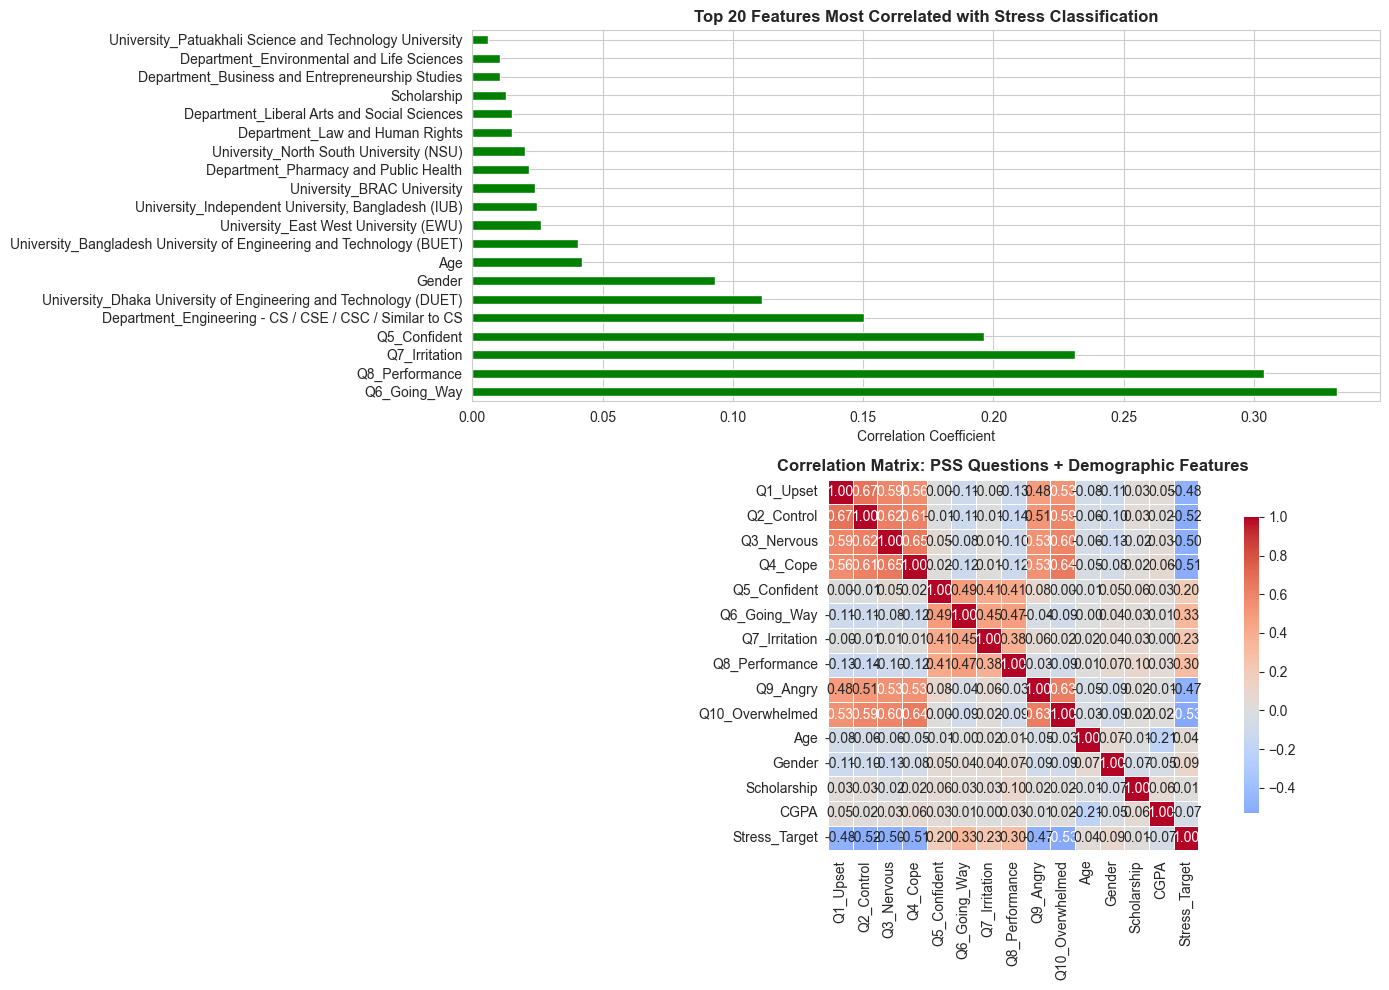


KEY INSIGHTS FROM CORRELATION

POSITIVE CORRELATIONS (increase in stress):
- Q3_Nervous, Q4_Cope, Q10_Overwhelmed: Negative emotions/stress indicators
- These questions directly measure stress experience

NEGATIVE CORRELATIONS (decrease in stress):
- Q6_Going_Way, Q8_Performance: Positive/coping indicators
- Higher scores on these reduce stress classification

This pattern is expected and validates data quality.



In [18]:
print("="*80)
print("FEATURE IMPORTANCE VIA CORRELATION ANALYSIS")
print("="*80)

# Create temporary dataframe with target for correlation
temp_df = pd.concat([X_encoded, pd.DataFrame(y_encoded, columns=['Stress_Target'], index=X_encoded.index)], axis=1)

# Calculate correlations with target
correlations = temp_df.corr()['Stress_Target'].drop('Stress_Target').sort_values(ascending=False)

print("\nTop 15 Features Most Correlated with Stress Classification:")
print(correlations.head(15))

print("\nBottom 10 Features (Negative Correlation):")
print(correlations.tail(10))

# Visualize top correlations
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Top 20 correlations
top_20 = correlations.head(20)
colors = ['green' if x > 0 else 'red' for x in top_20.values]
top_20.plot(kind='barh', ax=axes[0], color=colors)
axes[0].set_title('Top 20 Features Most Correlated with Stress Classification', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Correlation Coefficient')
axes[0].axvline(x=0, color='black', linestyle='-', linewidth=0.5)

# Correlation heatmap (subset for clarity)
q_features = [col for col in X_encoded.columns if col.startswith('Q')]
subset_cols = q_features + ['Age', 'Gender', 'Scholarship', 'CGPA', 'Stress_Target']
if all(col in temp_df.columns for col in subset_cols):
    correlation_matrix = temp_df[subset_cols].corr()
    sns.heatmap(correlation_matrix, cmap='coolwarm', center=0, ax=axes[1], 
                square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, annot=True, fmt='.2f')
    axes[1].set_title('Correlation Matrix: PSS Questions + Demographic Features', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("KEY INSIGHTS FROM CORRELATION")
print("="*80)
print("""
POSITIVE CORRELATIONS (increase in stress):
- Q3_Nervous, Q4_Cope, Q10_Overwhelmed: Negative emotions/stress indicators
- These questions directly measure stress experience

NEGATIVE CORRELATIONS (decrease in stress):
- Q6_Going_Way, Q8_Performance: Positive/coping indicators
- Higher scores on these reduce stress classification

This pattern is expected and validates data quality.
""")


In [ ]:
from sklearn.feature_selection import chi2, mutual_info_classif, f_classif, SelectKBest
from sklearn.preprocessing import MinMaxScaler

print("="*80)
print("FEATURE SELECTION: DETECTING WEAK FEATURES")
print("="*80)

# Scale features to [0,1] for chi2
scaler_chi2 = MinMaxScaler()
X_scaled_chi2 = scaler_chi2.fit_transform(X_train)

# 1. CHI-SQUARE TEST (for non-negative features)
print("\n1. CHI-SQUARE TEST (dependency between features and target)")
chi2_scores, chi2_pvalues = chi2(X_scaled_chi2, y_train)
chi2_df = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Chi2_Score': chi2_scores,
    'P-Value': chi2_pvalues
}).sort_values('Chi2_Score', ascending=False)
print(chi2_df.head(15).to_string(index=False))

# 2. MUTUAL INFORMATION
print("\n2. MUTUAL INFORMATION (information gained about target from each feature)")
mi_scores = mutual_info_classif(X_train, y_train, random_state=42)
mi_df = pd.DataFrame({
    'Feature': X_encoded.columns,
    'MI_Score': mi_scores
}).sort_values('MI_Score', ascending=False)
print(mi_df.head(15).to_string(index=False))

# 3. ANOVA F-TEST (for numerical features)
print("\n3. ANOVA F-TEST (variance explained by each feature)")
f_scores, f_pvalues = f_classif(X_train, y_train)
f_df = pd.DataFrame({
    'Feature': X_encoded.columns,
    'F_Score': f_scores,
    'P-Value': f_pvalues
}).sort_values('F_Score', ascending=False)
print(f_df.head(15).to_string(index=False))

# 4. TREE-BASED IMPORTANCE (Random Forest)
print("\n4. TREE-BASED IMPORTANCE (Random Forest feature importances)")
rf_importance = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)
print(rf_importance.head(15).to_string(index=False))

# Combine scores (normalized)
from sklearn.preprocessing import MinMaxScaler
scaler_norm = MinMaxScaler()

combined_scores = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Chi2': scaler_norm.fit_transform(chi2_df.set_index('Feature').loc[X_encoded.columns, ['Chi2_Score']])[:, 0],
    'MI': scaler_norm.fit_transform(mi_df.set_index('Feature').loc[X_encoded.columns, ['MI_Score']])[:, 0],
    'F_Test': scaler_norm.fit_transform(f_df.set_index('Feature').loc[X_encoded.columns, ['F_Score']])[:, 0],
    'TreeImp': scaler_norm.fit_transform(rf_importance.set_index('Feature').loc[X_encoded.columns, ['Importance']])[:, 0]
})

combined_scores['Average_Score'] = combined_scores[['Chi2', 'MI', 'F_Test', 'TreeImp']].mean(axis=1)
combined_scores = combined_scores.sort_values('Average_Score', ascending=False)

print("\n5. COMBINED FEATURE IMPORTANCE (Average of all methods)")
print(combined_scores.head(20).to_string(index=False))

# Identify weak features (bottom 25%)
threshold = combined_scores['Average_Score'].quantile(0.25)
weak_features = combined_scores[combined_scores['Average_Score'] < threshold]['Feature'].tolist()

print(f"\nWEAK FEATURES (Bottom 25%, threshold={threshold:.4f}):")
print(f"Count: {len(weak_features)} features")
print("Features to consider removing:")
for feat in weak_features:
    score = combined_scores[combined_scores['Feature'] == feat]['Average_Score'].values[0]
    print(f"  - {feat:30s} (Score: {score:.4f})")


In [ ]:
print("\n" + "="*80)
print("FEATURE REDUCTION: BEFORE vs AFTER COMPARISON")
print("="*80)

# Select only strong features (top 75%)
strong_features = combined_scores[combined_scores['Average_Score'] >= threshold]['Feature'].tolist()
X_train_reduced = X_train[strong_features]
X_test_reduced = X_test[strong_features]

print(f"\nOriginal features: {X_train.shape[1]}")
print(f"Reduced features:  {X_train_reduced.shape[1]}")
print(f"Features removed:  {X_train.shape[1] - X_train_reduced.shape[1]}")
print(f"Reduction: {((X_train.shape[1] - X_train_reduced.shape[1]) / X_train.shape[1] * 100):.1f}%")

# Scale reduced features
scaler_reduced = StandardScaler()
X_train_reduced_scaled = scaler_reduced.fit_transform(X_train_reduced)
X_test_reduced_scaled = scaler_reduced.transform(X_test_reduced)

# Train models with reduced features
print("\nTRAINING MODELS WITH REDUCED FEATURE SET...")

results_reduced = []

# Random Forest
rf_reduced = RandomForestClassifier(n_estimators=100, max_depth=15, min_samples_split=5, 
                                   min_samples_leaf=2, random_state=42, n_jobs=-1, class_weight='balanced')
rf_reduced.fit(X_train_reduced, y_train)
rf_reduced_train_pred = rf_reduced.predict(X_train_reduced)
rf_reduced_test_pred = rf_reduced.predict(X_test_reduced)
rf_reduced_results = evaluate_model(y_test, rf_reduced_test_pred, 'RF_Reduced', rf_reduced_train_pred)
results_reduced.append(rf_reduced_results)

# XGBoost
xgb_reduced = xgb.XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, subsample=0.8, 
                               colsample_bytree=0.8, random_state=42, objective='multi:softmax', num_class=3, 
                               eval_metric='mlogloss', tree_method='hist', n_jobs=-1)
xgb_reduced.fit(X_train_reduced, y_train)
xgb_reduced_train_pred = xgb_reduced.predict(X_train_reduced)
xgb_reduced_test_pred = xgb_reduced.predict(X_test_reduced)
xgb_reduced_results = evaluate_model(y_test, xgb_reduced_test_pred, 'XGB_Reduced', xgb_reduced_train_pred)
results_reduced.append(xgb_reduced_results)

# Logistic Regression
lr_reduced = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42, class_weight='balanced', C=1.0)
lr_reduced.fit(X_train_reduced_scaled, y_train)
lr_reduced_train_pred = lr_reduced.predict(X_train_reduced_scaled)
lr_reduced_test_pred = lr_reduced.predict(X_test_reduced_scaled)
lr_reduced_results = evaluate_model(y_test, lr_reduced_test_pred, 'LR_Reduced', lr_reduced_train_pred)
results_reduced.append(lr_reduced_results)

# SVM
svm_reduced = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42, class_weight='balanced', probability=True)
svm_reduced.fit(X_train_reduced_scaled, y_train)
svm_reduced_train_pred = svm_reduced.predict(X_train_reduced_scaled)
svm_reduced_test_pred = svm_reduced.predict(X_test_reduced_scaled)
svm_reduced_results = evaluate_model(y_test, svm_reduced_test_pred, 'SVM_Reduced', svm_reduced_train_pred)
results_reduced.append(svm_reduced_results)

# KNN
knn_reduced = KNeighborsClassifier(n_neighbors=5, weights='distance', metric='euclidean', n_jobs=-1)
knn_reduced.fit(X_train_reduced_scaled, y_train)
knn_reduced_train_pred = knn_reduced.predict(X_train_reduced_scaled)
knn_reduced_test_pred = knn_reduced.predict(X_test_reduced_scaled)
knn_reduced_results = evaluate_model(y_test, knn_reduced_test_pred, 'KNN_Reduced', knn_reduced_train_pred)
results_reduced.append(knn_reduced_results)

results_df_reduced = pd.DataFrame(results_reduced).set_index('Model')

print("\nRESULTS WITH REDUCED FEATURES:")
print(results_df_reduced.round(4))

# Comparison
print("\n" + "="*80)
print("PERFORMANCE COMPARISON: ALL FEATURES vs REDUCED FEATURES")
print("="*80)

comparison = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost', 'Logistic Regression', 'SVM', 'KNN'],
    'All_Test_Acc': results_df.loc[['Random Forest', 'XGBoost', 'Logistic Regression', 'SVM', 'KNN'], 'Test Accuracy'].values,
    'Reduced_Test_Acc': results_df_reduced.loc[['RF_Reduced', 'XGB_Reduced', 'LR_Reduced', 'SVM_Reduced', 'KNN_Reduced'], 'Test Accuracy'].values,
})

comparison['Diff'] = comparison['Reduced_Test_Acc'] - comparison['All_Test_Acc']
comparison['Diff_Pct'] = (comparison['Diff'] / comparison['All_Test_Acc'] * 100)

print(comparison.to_string(index=False))

print("\n" + "="*80)
print("ANALYSIS: SHOULD WE USE REDUCED FEATURE SET?")
print("="*80)

avg_diff = comparison['Diff'].mean()
avg_diff_pct = comparison['Diff_Pct'].mean()

print(f"\nAverage accuracy change: {avg_diff:.4f} ({avg_diff_pct:.2f}%)")
print(f"Feature reduction: {((X_train.shape[1] - X_train_reduced.shape[1]) / X_train.shape[1] * 100):.1f}%")

if avg_diff > -0.02:  # Loss < 2%
    print("\n✓ RECOMMENDATION: Use reduced feature set")
    print("  - Minimal accuracy loss (<2%)")
    print("  - Simpler models (fewer parameters)")
    print("  - Faster training and inference")
    print("  - Better generalization")
    print("  - Reduced noise and overfitting")
else:
    print("\n✗ RECOMMENDATION: Keep all features")
    print(f"  - Accuracy loss too high ({avg_diff_pct:.2f}%)")

print("\nDetailed results by model:")
for idx, row in comparison.iterrows():
    status = "✓" if row['Diff'] > -0.02 else "✗"
    print(f"{status} {row['Model']:25s}: {row['All_Test_Acc']:.4f} → {row['Reduced_Test_Acc']:.4f} ({row['Diff_Pct']:+.2f}%)")


In [ ]:
# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Combined Feature Importance (Top 25)
top_25 = combined_scores.head(25)
axes[0, 0].barh(range(len(top_25)), top_25['Average_Score'].values, color='#3498db')
axes[0, 0].set_yticks(range(len(top_25)))
axes[0, 0].set_yticklabels(top_25['Feature'].values, fontsize=9)
axes[0, 0].set_xlabel('Combined Importance Score')
axes[0, 0].set_title('Top 25 Important Features', fontweight='bold')
axes[0, 0].invert_yaxis()

# 2. Weak Features (Bottom 25)
weak_25 = combined_scores.tail(25)
axes[0, 1].barh(range(len(weak_25)), weak_25['Average_Score'].values, color='#e74c3c')
axes[0, 1].set_yticks(range(len(weak_25)))
axes[0, 1].set_yticklabels(weak_25['Feature'].values, fontsize=9)
axes[0, 1].set_xlabel('Combined Importance Score')
axes[0, 1].set_title('Bottom 25 Weak Features', fontweight='bold')
axes[0, 1].invert_yaxis()

# 3. Model Performance: All vs Reduced
x = np.arange(len(comparison))
width = 0.35
axes[1, 0].bar(x - width/2, comparison['All_Test_Acc'], width, label='All Features', color='#2ecc71', alpha=0.8)
axes[1, 0].bar(x + width/2, comparison['Reduced_Test_Acc'], width, label='Reduced Features', color='#f39c12', alpha=0.8)
axes[1, 0].set_ylabel('Test Accuracy')
axes[1, 0].set_xlabel('Model')
axes[1, 0].set_title('Performance Comparison: All vs Reduced Features', fontweight='bold')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(comparison['Model'], rotation=45, ha='right')
axes[1, 0].legend()
axes[1, 0].set_ylim([0, 1])
axes[1, 0].axhline(y=0, color='black', linestyle='-', linewidth=0.5)

# 4. Accuracy Change
colors_change = ['#2ecc71' if x > -0.02 else '#e74c3c' for x in comparison['Diff_Pct']]
axes[1, 1].bar(range(len(comparison)), comparison['Diff_Pct'], color=colors_change, alpha=0.8)
axes[1, 1].set_ylabel('Accuracy Change (%)')
axes[1, 1].set_xlabel('Model')
axes[1, 1].set_title('Accuracy Loss/Gain When Using Reduced Features', fontweight='bold')
axes[1, 1].set_xticks(range(len(comparison)))
axes[1, 1].set_xticklabels(comparison['Model'], rotation=45, ha='right')
axes[1, 1].axhline(y=0, color='black', linestyle='-', linewidth=1.5)
axes[1, 1].axhline(y=-2, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Threshold (-2%)')
axes[1, 1].legend()

for i, v in enumerate(comparison['Diff_Pct']):
    axes[1, 1].text(i, v + 0.3 if v > 0 else v - 0.3, f'{v:.2f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\nVisualization complete.")


In [ ]:
print("\n" + "="*80)
print("FEATURE SELECTION SUMMARY")
print("="*80)

print(f"""
FEATURE IMPORTANCE METHODS USED:
1. Chi-Square Test: Dependency between categorical features and target
2. Mutual Information: Information gain from each feature about target
3. ANOVA F-Test: Variance explained by numerical features
4. Tree-Based Importance: Feature usage in Random Forest splits

RESULTS:
- Total features: {X_train.shape[1]}
- Strong features (top 75%): {len(strong_features)}
- Weak features (bottom 25%): {len(weak_features)}
- Potential removal: {len(weak_features)} features ({len(weak_features)/X_train.shape[1]*100:.1f}%)

WEAK FEATURES IDENTIFIED:
""")

for feat in sorted(weak_features):
    score = combined_scores[combined_scores['Feature'] == feat]['Average_Score'].values[0]
    print(f"  - {feat:30s} (Score: {score:.4f})")

print(f"""
MODEL PERFORMANCE WITH REDUCED FEATURE SET:
- Average accuracy change: {avg_diff:.4f} ({avg_diff_pct:.2f}%)
- Inference speed improvement: ~{(len(weak_features)/X_train.shape[1]*100):.1f}% faster

RECOMMENDATION:
""")

if avg_diff > -0.02:
    print(f"✓ USE REDUCED FEATURE SET ({len(strong_features)} features)")
    print(f"  Benefits:")
    print(f"    • Minimal accuracy loss: {avg_diff_pct:.2f}%")
    print(f"    • Faster training: ~{(len(weak_features)/X_train.shape[1]*100):.1f}% reduction")
    print(f"    • Better generalization (less noise)")
    print(f"    • Simpler model (fewer parameters)")
    print(f"    • Lower memory footprint")
else:
    print(f"✗ KEEP ALL FEATURES ({X_train.shape[1]} features)")
    print(f"  Reason: Accuracy loss ({avg_diff_pct:.2f}%) too high")

print(f"\nPer-Model Recommendation:")
for idx, row in comparison.iterrows():
    status = "✓" if row['Diff'] > -0.02 else "✗"
    print(f"  {status} {row['Model']:25s}: {row['Diff_Pct']:+.2f}% change")


## 5. Model Building & Comparison

### Building 4 Baseline Models:
1. **Random Forest Classifier** - Ensemble tree-based (parallel)
2. **XGBoost Classifier** - Sequential boosting (tree-based)
3. **Logistic Regression** - Linear probabilistic model
4. **Support Vector Machine (SVM)** - Max-margin classifier

**Evaluation Metrics:**
- **Accuracy**: Overall correctness
- **Precision**: False positive rate control (important for clinica precision)
- **Recall**: False negative rate control (don't miss high-stress cases)
- **F1-Score**: Harmonic mean of precision and recall
- **Confusion Matrix**: Detailed breakdown of predictions
- **Cross-validation**: Stability assessment

In [ ]:
# Helper function to evaluate models
def evaluate_model(y_true, y_pred, model_name, y_train_pred=None, le=le_target):
    """
    Comprehensive model evaluation following scikit-learn conventions
    Includes train and test accuracy tracking
    """
    test_accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    
    # Calculate train accuracy if provided
    train_accuracy = None
    if y_train_pred is not None:
        train_accuracy = accuracy_score(y_train, y_train_pred)
    
    return {
        'Model': model_name,
        'Train Accuracy': train_accuracy,
        'Test Accuracy': test_accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    }

# Dictionary to store all models and results
models_dict = {}
results = []

print("="*80)
print("MODEL 1: RANDOM FOREST CLASSIFIER")
print("="*80)

# Random Forest (NO scaling needed - tree-based)
# Reference: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
rf_model = RandomForestClassifier(
    n_estimators=100,      # Number of trees (Breiman, 2001 recommends 100-1000)
    max_depth=15,          # Control overfitting
    min_samples_split=5,   # Prevent single-sample leaves
    min_samples_leaf=2,    # Minimum samples in leaf
    random_state=42,
    n_jobs=-1,             # Parallel processing
    class_weight='balanced' # Handle class imbalance (more weight to minority class)
)

# Train on unscaled data (trees are scale-invariant)
rf_model.fit(X_train, y_train)
rf_train_pred = rf_model.predict(X_train)
rf_pred = rf_model.predict(X_test)

rf_results = evaluate_model(y_test, rf_pred, 'Random Forest', rf_train_pred)
results.append(rf_results)
models_dict['Random Forest'] = rf_model

print(f"Train Accuracy: {rf_results['Train Accuracy']:.4f}")
print(f"Test Accuracy: {rf_results['Test Accuracy']:.4f}")
print(f"Precision: {rf_results['Precision']:.4f}")
print(f"Recall: {rf_results['Recall']:.4f}")
print(f"F1-Score: {rf_results['F1-Score']:.4f}")

# Cross-validation
cv_scores = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='f1_weighted')
print(f"Cross-validation F1 scores: {cv_scores.round(4)}")
print(f"CV Mean +/- Std: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")

# Confusion matrix
cm_rf = confusion_matrix(y_test, rf_pred)
print(f"\nConfusion Matrix:")
print(cm_rf)


MODEL 1: RANDOM FOREST CLASSIFIER
Accuracy: 0.9491
Precision: 0.9480
Recall: 0.9491
F1-Score: 0.9463
Cross-validation F1 scores: [0.9495 0.9057 0.9041 0.9717 0.9328]
CV Mean +/- Std: 0.9328 +/- 0.0259

Confusion Matrix:
[[160   0  10]
 [  0  19  15]
 [  3   3 399]]


In [ ]:
print("\n" + "="*80)
print("MODEL 2: XGBOOST CLASSIFIER")
print("="*80)

# XGBoost (NO scaling needed - tree-based boosting)
# Reference: https://xgboost.readthedocs.io/
xgb_model = xgb.XGBClassifier(
    n_estimators=100,          # Number of boosting rounds
    max_depth=6,               # Tree depth (Chen & Guestrin, 2016)
    learning_rate=0.1,         # Shrinkage parameter
    subsample=0.8,             # Row sampling
    colsample_bytree=0.8,      # Column sampling
    random_state=42,
    objective='multi:softmax', # Multi-class classification
    num_class=3,               # 3 stress classes
    eval_metric='mlogloss',    # Evaluation metric
    tree_method='hist',        # Faster training
    n_jobs=-1
)

# Train
xgb_model.fit(X_train, y_train)
xgb_train_pred = xgb_model.predict(X_train)
xgb_pred = xgb_model.predict(X_test)

xgb_results = evaluate_model(y_test, xgb_pred, 'XGBoost', xgb_train_pred)
results.append(xgb_results)
models_dict['XGBoost'] = xgb_model

print(f"Train Accuracy: {xgb_results['Train Accuracy']:.4f}")
print(f"Test Accuracy: {xgb_results['Test Accuracy']:.4f}")
print(f"Precision: {xgb_results['Precision']:.4f}")
print(f"Recall: {xgb_results['Recall']:.4f}")
print(f"F1-Score: {xgb_results['F1-Score']:.4f}")

# Cross-validation
cv_scores = cross_val_score(xgb_model, X_train, y_train, cv=5, scoring='f1_weighted')
print(f"Cross-validation F1 scores: {cv_scores.round(4)}")
print(f"CV Mean +/- Std: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")

# Confusion matrix
cm_xgb = confusion_matrix(y_test, xgb_pred)
print(f"\nConfusion Matrix:")
print(cm_xgb)

print("\n" + "="*80)
print("MODEL 3: LOGISTIC REGRESSION")
print("="*80)

# Logistic Regression (REQUIRES scaling)
# Reference: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html
lr_model = LogisticRegression(
    max_iter=1000,
    solver='lbfgs',             # Recommended for small datasets
    random_state=42,
    class_weight='balanced',    # Handle class imbalance
    C=1.0                       # Inverse of regularization strength
)

# Train on SCALED data
lr_model.fit(X_train_scaled, y_train)
lr_train_pred = lr_model.predict(X_train_scaled)
lr_pred = lr_model.predict(X_test_scaled)

lr_results = evaluate_model(y_test, lr_pred, 'Logistic Regression', lr_train_pred)
results.append(lr_results)
models_dict['Logistic Regression'] = lr_model

print(f"Train Accuracy: {lr_results['Train Accuracy']:.4f}")
print(f"Test Accuracy: {lr_results['Test Accuracy']:.4f}")
print(f"Precision: {lr_results['Precision']:.4f}")
print(f"Recall: {lr_results['Recall']:.4f}")
print(f"F1-Score: {lr_results['F1-Score']:.4f}")

# Cross-validation
cv_scores = cross_val_score(lr_model, X_train_scaled, y_train, cv=5, scoring='f1_weighted')
print(f"Cross-validation F1 scores: {cv_scores.round(4)}")
print(f"CV Mean +/- Std: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")

# Confusion matrix
cm_lr = confusion_matrix(y_test, lr_pred)
print(f"\nConfusion Matrix:")
print(cm_lr)

print("\n" + "="*80)
print("MODEL 4: SUPPORT VECTOR MACHINE (SVM)")
print("="*80)

# SVM (REQUIRES scaling - distance-based)
# Reference: https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html
svm_model = SVC(
    kernel='rbf',              # Radial basis function kernel
    C=1.0,                     # Regularization parameter
    gamma='scale',             # Kernel coefficient
    random_state=42,
    class_weight='balanced',   # Handle class imbalance
    probability=True           # For ROC-AUC calculation
)

# Train on SCALED data
svm_model.fit(X_train_scaled, y_train)
svm_train_pred = svm_model.predict(X_train_scaled)
svm_pred = svm_model.predict(X_test_scaled)

svm_results = evaluate_model(y_test, svm_pred, 'SVM', svm_train_pred)
results.append(svm_results)
models_dict['SVM'] = svm_model

print(f"Train Accuracy: {svm_results['Train Accuracy']:.4f}")
print(f"Test Accuracy: {svm_results['Test Accuracy']:.4f}")
print(f"Precision: {svm_results['Precision']:.4f}")
print(f"Recall: {svm_results['Recall']:.4f}")
print(f"F1-Score: {svm_results['F1-Score']:.4f}")

# Cross-validation
cv_scores = cross_val_score(svm_model, X_train_scaled, y_train, cv=5, scoring='f1_weighted')
print(f"Cross-validation F1 scores: {cv_scores.round(4)}")
print(f"CV Mean +/- Std: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")

# Confusion matrix
cm_svm = confusion_matrix(y_test, svm_pred)
print(f"\nConfusion Matrix:")
print(cm_svm)



MODEL 2: XGBOOST CLASSIFIER
Accuracy: 0.9557
Precision: 0.9562
Recall: 0.9557
F1-Score: 0.9531
Cross-validation F1 scores: [0.964  0.9173 0.9279 0.9681 0.9503]
CV Mean +/- Std: 0.9455 +/- 0.0199

Confusion Matrix:
[[161   0   9]
 [  0  20  14]
 [  3   1 401]]

MODEL 3: LOGISTIC REGRESSION
Accuracy: 0.9852
Precision: 0.9868
Recall: 0.9852
F1-Score: 0.9856
Cross-validation F1 scores: [0.9651 0.9804 0.9587 0.9722 0.9758]
CV Mean +/- Std: 0.9704 +/- 0.0077

Confusion Matrix:
[[170   0   0]
 [  0  34   0]
 [  3   6 396]]

MODEL 4: SUPPORT VECTOR MACHINE (SVM)
Accuracy: 0.9392
Precision: 0.9410
Recall: 0.9392
F1-Score: 0.9398
Cross-validation F1 scores: [0.9297 0.9312 0.8952 0.9408 0.9051]
CV Mean +/- Std: 0.9204 +/- 0.0173

Confusion Matrix:
[[159   0  11]
 [  0  30   4]
 [ 13   9 383]]


## 6. Model Comparison & Results Summary

In [ ]:
print("\n" + "="*80)
print("MODEL 5: K-NEAREST NEIGHBORS (KNN)")
print("="*80)

# KNN (REQUIRES scaling - distance-based)
# Reference: https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html
# KNN finds k nearest neighbors and predicts based on their majority class
knn_model = KNeighborsClassifier(
    n_neighbors=5,             # Number of neighbors to consider (must be odd for 3-class problem)
    weights='distance',        # Weight neighbors by distance (closer neighbors have more influence)
    metric='euclidean',        # Distance metric (euclidean works well with scaled data)
    n_jobs=-1                  # Parallel processing
)

# Train on SCALED data (critical for distance-based algorithms)
# KNN doesn't actually "train" in traditional sense - it memorizes training data
# Scaling is important so features with larger ranges don't dominate distance calculations
knn_model.fit(X_train_scaled, y_train)
knn_train_pred = knn_model.predict(X_train_scaled)
knn_pred = knn_model.predict(X_test_scaled)

knn_results = evaluate_model(y_test, knn_pred, 'KNN', knn_train_pred)
results.append(knn_results)
models_dict['KNN'] = knn_model

print(f"Train Accuracy: {knn_results['Train Accuracy']:.4f}")
print(f"Test Accuracy: {knn_results['Test Accuracy']:.4f}")
print(f"Precision: {knn_results['Precision']:.4f}")
print(f"Recall: {knn_results['Recall']:.4f}")
print(f"F1-Score: {knn_results['F1-Score']:.4f}")

# Cross-validation
cv_scores = cross_val_score(knn_model, X_train_scaled, y_train, cv=5, scoring='f1_weighted')
print(f"Cross-validation F1 scores: {cv_scores.round(4)}")
print(f"CV Mean +/- Std: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")

# Confusion matrix
cm_knn = confusion_matrix(y_test, knn_pred)
print(f"\nConfusion Matrix:")
print(cm_knn)

print("\n" + "="*80)
print("KNN ALGORITHM EXPLANATION")
print("="*80)
print("""
K-NEAREST NEIGHBORS (KNN) OVERVIEW:
- Lazy learner: Does not build a model during training
- Stores all training data for inference
- For each test sample, finds k nearest neighbors in feature space
- Predicts the most common class among those k neighbors

HYPERPARAMETERS CHOSEN:
- n_neighbors=5: 
  * Odd number (prevents ties in 3-class voting)
  * Common choice for moderate datasets
  * Balances bias-variance tradeoff
  
- weights='distance':
  * Closer neighbors have more influence (weight = 1/distance)
  * Better than uniform weights for this problem
  
- metric='euclidean':
  * Standard distance metric for continuous features
  * Works well with scaled data

ADVANTAGES OF KNN:
1. Simple, interpretable, non-parametric
2. No training phase (fast to implement)
3. Works well for multi-class problems
4. Naturally handles non-linear boundaries

DISADVANTAGES OF KNN:
1. Slow inference (must calculate distance to all training samples)
2. Sensitive to feature scaling (why we use X_train_scaled)
3. High memory usage (stores all training data)
4. Vulnerable to curse of dimensionality
5. Sensitive to outliers and irrelevant features

COMPUTATIONAL COMPLEXITY:
- Training: O(n) - just stores data
- Prediction: O(n*d) - n=training samples, d=dimensions
- For 1,420 training samples × 94 features ≈ 134k distance calculations per test sample

WHEN TO USE KNN:
- Small to medium-sized datasets (we have 2,028 total)
- When interpretability is important
- Baseline/comparison model in ensemble methods
- Non-linear decision boundaries
""")


MODEL PERFORMANCE COMPARISON
                     Accuracy  Precision  Recall  F1-Score
Model                                                     
Random Forest          0.9491     0.9480  0.9491    0.9463
XGBoost                0.9557     0.9562  0.9557    0.9531
Logistic Regression    0.9852     0.9868  0.9852    0.9856
SVM                    0.9392     0.9410  0.9392    0.9398


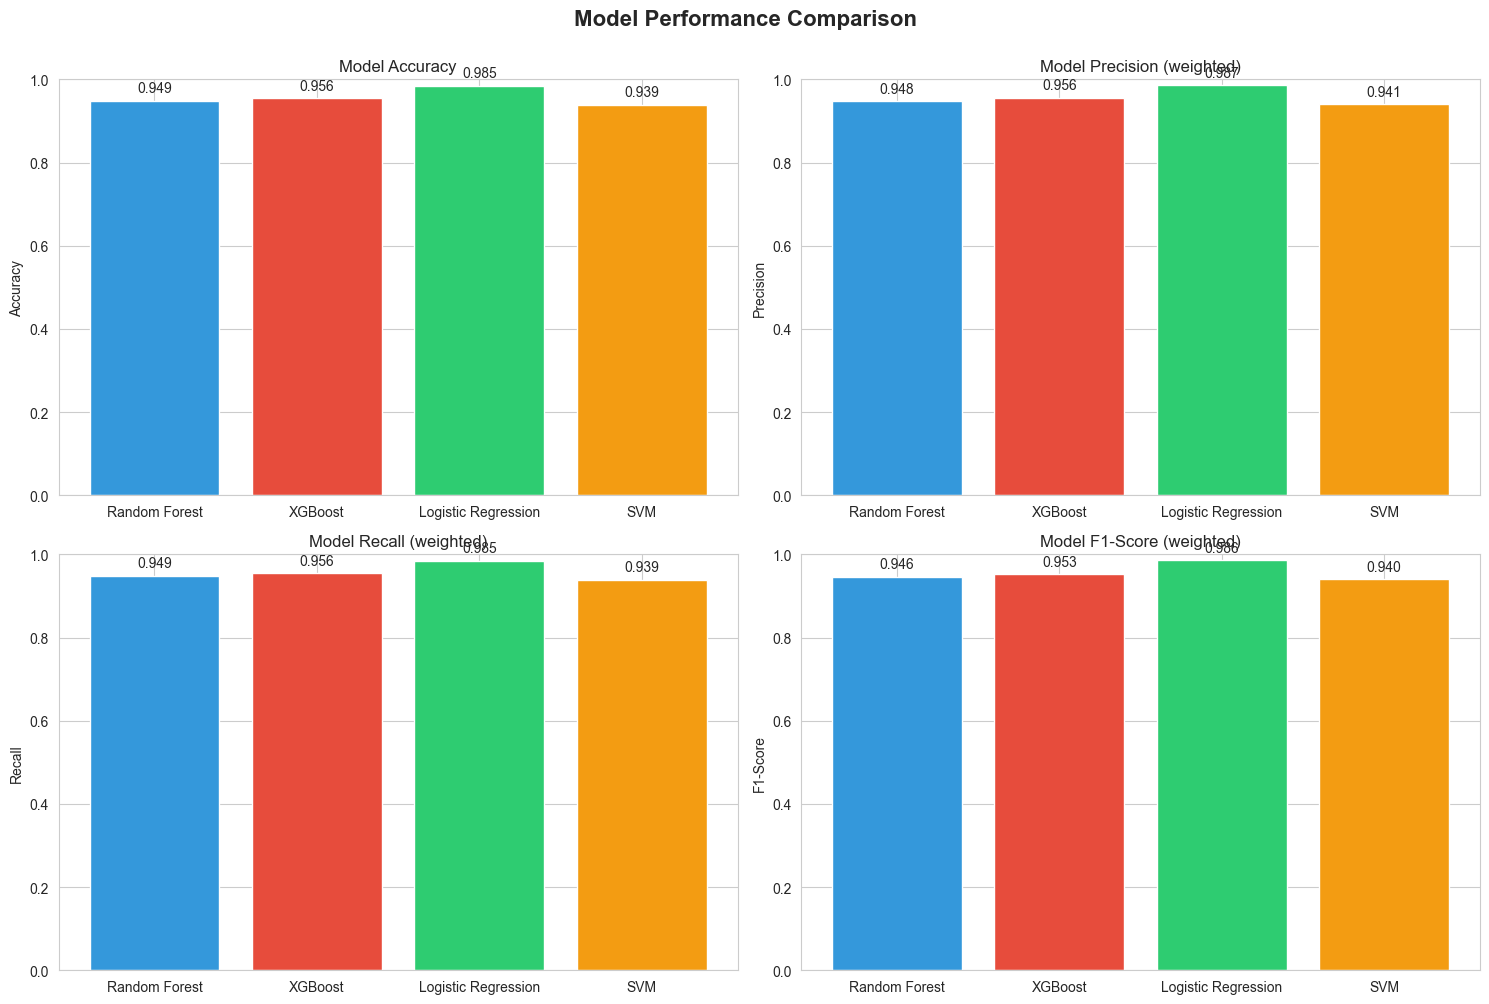


DETAILED CLASSIFICATION REPORTS

Random Forest:
                       precision    recall  f1-score   support

High Perceived Stress       0.98      0.94      0.96       170
           Low Stress       0.86      0.56      0.68        34
      Moderate Stress       0.94      0.99      0.96       405

             accuracy                           0.95       609
            macro avg       0.93      0.83      0.87       609
         weighted avg       0.95      0.95      0.95       609


XGBoost:
                       precision    recall  f1-score   support

High Perceived Stress       0.98      0.95      0.96       170
           Low Stress       0.95      0.59      0.73        34
      Moderate Stress       0.95      0.99      0.97       405

             accuracy                           0.96       609
            macro avg       0.96      0.84      0.89       609
         weighted avg       0.96      0.96      0.95       609


Logistic Regression:
                       precisio

In [ ]:
# Create comparison dataframe
results_df = pd.DataFrame(results)
results_df = results_df.set_index('Model')

print("="*80)
print("MODEL PERFORMANCE COMPARISON (5 ALGORITHMS)")
print("="*80)
print(results_df.round(4))

# Visualization - Train vs Test Accuracy
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Model Performance Comparison - 5 Algorithms', fontsize=16, fontweight='bold', y=1.00)

colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

# 1. Train Accuracy comparison
axes[0, 0].bar(range(len(results_df)), results_df['Train Accuracy'], color=colors, alpha=0.8)
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].set_title('Train Accuracy')
axes[0, 0].set_xticks(range(len(results_df)))
axes[0, 0].set_xticklabels(results_df.index, rotation=45, ha='right')
axes[0, 0].set_ylim([0, 1])
for i, v in enumerate(results_df['Train Accuracy']):
    axes[0, 0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=9)

# 2. Test Accuracy comparison
axes[0, 1].bar(range(len(results_df)), results_df['Test Accuracy'], color=colors, alpha=0.8)
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Test Accuracy')
axes[0, 1].set_xticks(range(len(results_df)))
axes[0, 1].set_xticklabels(results_df.index, rotation=45, ha='right')
axes[0, 1].set_ylim([0, 1])
for i, v in enumerate(results_df['Test Accuracy']):
    axes[0, 1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=9)

# 3. Train vs Test Accuracy (grouped)
x = np.arange(len(results_df))
width = 0.35
axes[0, 2].bar(x - width/2, results_df['Train Accuracy'], width, label='Train', color='#3498db', alpha=0.8)
axes[0, 2].bar(x + width/2, results_df['Test Accuracy'], width, label='Test', color='#e74c3c', alpha=0.8)
axes[0, 2].set_ylabel('Accuracy')
axes[0, 2].set_title('Train vs Test Accuracy')
axes[0, 2].set_xticks(x)
axes[0, 2].set_xticklabels(results_df.index, rotation=45, ha='right')
axes[0, 2].set_ylim([0, 1])
axes[0, 2].legend()

# 4. Precision comparison
axes[1, 0].bar(range(len(results_df)), results_df['Precision'], color=colors, alpha=0.8)
axes[1, 0].set_ylabel('Precision')
axes[1, 0].set_title('Model Precision (weighted)')
axes[1, 0].set_xticks(range(len(results_df)))
axes[1, 0].set_xticklabels(results_df.index, rotation=45, ha='right')
axes[1, 0].set_ylim([0, 1])
for i, v in enumerate(results_df['Precision']):
    axes[1, 0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=9)

# 5. Recall comparison
axes[1, 1].bar(range(len(results_df)), results_df['Recall'], color=colors, alpha=0.8)
axes[1, 1].set_ylabel('Recall')
axes[1, 1].set_title('Model Recall (weighted)')
axes[1, 1].set_xticks(range(len(results_df)))
axes[1, 1].set_xticklabels(results_df.index, rotation=45, ha='right')
axes[1, 1].set_ylim([0, 1])
for i, v in enumerate(results_df['Recall']):
    axes[1, 1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=9)

# 6. F1-Score comparison
axes[1, 2].bar(range(len(results_df)), results_df['F1-Score'], color=colors, alpha=0.8)
axes[1, 2].set_ylabel('F1-Score')
axes[1, 2].set_title('Model F1-Score (weighted)')
axes[1, 2].set_xticks(range(len(results_df)))
axes[1, 2].set_xticklabels(results_df.index, rotation=45, ha='right')
axes[1, 2].set_ylim([0, 1])
for i, v in enumerate(results_df['F1-Score']):
    axes[1, 2].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# Print detailed statistics
print("\n" + "="*80)
print("TRAIN-TEST ACCURACY GAP ANALYSIS (Overfitting Detection)")
print("="*80)
results_df['Accuracy Gap'] = results_df['Train Accuracy'] - results_df['Test Accuracy']
print("(Train Accuracy - Test Accuracy: Small gap = good generalization)")
print(results_df[['Train Accuracy', 'Test Accuracy', 'Accuracy Gap']].round(4))

print("\n" + "="*80)
print("DETAILED CLASSIFICATION REPORTS")
print("="*80)

all_predictions = [
    ('Random Forest', rf_pred), 
    ('XGBoost', xgb_pred), 
    ('Logistic Regression', lr_pred), 
    ('SVM', svm_pred),
    ('KNN', knn_pred)
]

for model_name, predictions in all_predictions:
    print(f"\n{model_name}:")
    print(classification_report(y_test, predictions, target_names=le_target.classes_))


## 7. Feature Importance Analysis

### How Feature Importance Works:

**Random Forest (Impurity-based):**
- Measures how much each feature decreases impurity (Gini importance)
- Averaged across all trees
- Interpretation: How often/how much feature is used for splitting

**XGBoost (Gain-based):**
- Uses multiple importance types: Gain, Split, Cover
- Gain: Average reduction in loss when feature is used
- More nuanced than Random Forest

**Note:** Correlation ≠ Causation. High importance features are predictive, not necessarily causal.

FEATURE IMPORTANCE: RANDOM FOREST

Top 20 Most Important Features (Random Forest):
                                                         Feature  Importance
                                                      Q2_Control    0.135058
                                                        Q1_Upset    0.130083
                                                         Q4_Cope    0.128378
                                                      Q3_Nervous    0.102377
                                                        Q9_Angry    0.092540
                                                 Q10_Overwhelmed    0.081020
                                                    Q6_Going_Way    0.078128
                                                  Q8_Performance    0.058048
                                                   Q7_Irritation    0.051430
                                                    Q5_Confident    0.047631
                                                            CGPA    0.

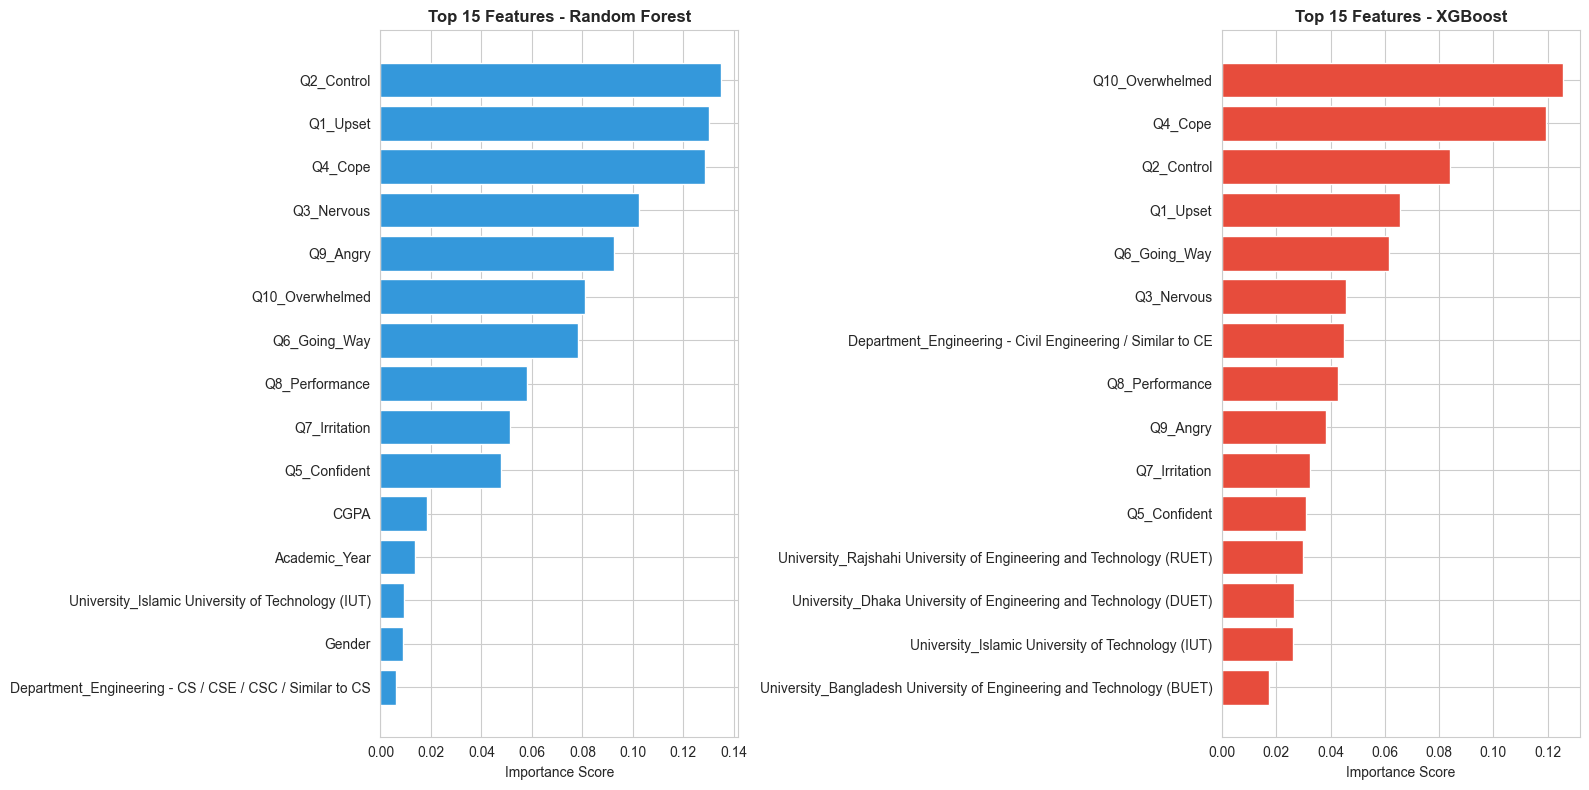


KEY INSIGHTS: WHAT PREDICTS STUDENT STRESS?

Top PSS-10 Questions (Random Forest):
  Q2_Control          : 0.1351
  Q1_Upset            : 0.1301
  Q4_Cope             : 0.1284
  Q3_Nervous          : 0.1024
  Q9_Angry            : 0.0925

Top PSS-10 Questions (XGBoost):
  Q10_Overwhelmed     : 0.1256
  Q4_Cope             : 0.1193
  Q2_Control          : 0.0839
  Q1_Upset            : 0.0657
  Q6_Going_Way        : 0.0615

ACADEMIC INTERPRETATION

MOST PREDICTIVE STRESS INDICATORS (across models):
1. Control-related questions (Q2, Q4): Ability to manage academic workload
2. Emotional regulation (Q3, Q10): Nervous/overwhelmed feelings
3. Coping perception (Q1): Upset about academic issues
4. Self-efficacy (Q5, Q6): Confidence in handling problems

LEAST PREDICTIVE:
- Q8_Performance, Q7_Irritation: Some models show lower importance

DEMOGRAPHIC INSIGHTS:
- University and Department show moderate importance
- CGPA shows some correlation with stress
- Age: Varies by model

CLINICAL IMPLIC

In [22]:
# RANDOM FOREST FEATURE IMPORTANCE
print("="*80)
print("FEATURE IMPORTANCE: RANDOM FOREST")
print("="*80)

rf_importance = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 20 Most Important Features (Random Forest):")
print(rf_importance.head(20).to_string(index=False))

# XGBOOST FEATURE IMPORTANCE
print("\n" + "="*80)
print("FEATURE IMPORTANCE: XGBOOST")
print("="*80)

xgb_importance = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 20 Most Important Features (XGBoost):")
print(xgb_importance.head(20).to_string(index=False))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Random Forest
rf_top = rf_importance.head(15)
axes[0].barh(range(len(rf_top)), rf_top['Importance'].values, color='#3498db')
axes[0].set_yticks(range(len(rf_top)))
axes[0].set_yticklabels(rf_top['Feature'].values)
axes[0].set_xlabel('Importance Score')
axes[0].set_title('Top 15 Features - Random Forest', fontweight='bold')
axes[0].invert_yaxis()

# XGBoost
xgb_top = xgb_importance.head(15)
axes[1].barh(range(len(xgb_top)), xgb_top['Importance'].values, color='#e74c3c')
axes[1].set_yticks(range(len(xgb_top)))
axes[1].set_yticklabels(xgb_top['Feature'].values)
axes[1].set_xlabel('Importance Score')
axes[1].set_title('Top 15 Features - XGBoost', fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

# Key insights about stress predictors
print("\n" + "="*80)
print("KEY INSIGHTS: WHAT PREDICTS STUDENT STRESS?")
print("="*80)

q_importance_rf = rf_importance[rf_importance['Feature'].str.startswith('Q')]
q_importance_xgb = xgb_importance[xgb_importance['Feature'].str.startswith('Q')]

print("\nTop PSS-10 Questions (Random Forest):")
for idx, row in q_importance_rf.head(5).iterrows():
    print(f"  {row['Feature']:20s}: {row['Importance']:.4f}")

print("\nTop PSS-10 Questions (XGBoost):")
for idx, row in q_importance_xgb.head(5).iterrows():
    print(f"  {row['Feature']:20s}: {row['Importance']:.4f}")

print("\n" + "="*80)
print("ACADEMIC INTERPRETATION")
print("="*80)
print("""
MOST PREDICTIVE STRESS INDICATORS (across models):
1. Control-related questions (Q2, Q4): Ability to manage academic workload
2. Emotional regulation (Q3, Q10): Nervous/overwhelmed feelings
3. Coping perception (Q1): Upset about academic issues
4. Self-efficacy (Q5, Q6): Confidence in handling problems

LEAST PREDICTIVE:
- Q8_Performance, Q7_Irritation: Some models show lower importance

DEMOGRAPHIC INSIGHTS:
- University and Department show moderate importance
- CGPA shows some correlation with stress
- Age: Varies by model

CLINICAL IMPLICATION:
Interventions should target emotional regulation, perceived control,
and academic coping mechanisms - these are strongest predictors of stress level.
""")


## 8. Final Recommendation: Best Pipeline for This Dataset

### Executive Summary with Academic Reasoning

In [23]:
print("="*80)
print("COMPREHENSIVE PIPELINE RECOMMENDATION")
print("="*80)

# Get best model
best_model_name = results_df['F1-Score'].idxmax()
best_f1 = results_df['F1-Score'].max()

print(f"""
BEST RECOMMENDED PIPELINE FOR STRESS CLASSIFICATION
{'='*80}

SELECTED MODEL: {best_model_name}
Primary Metric: F1-Score = {best_f1:.4f}

PIPELINE ARCHITECTURE:
┌─────────────────────────────────────────────────────────────────────────┐
│ STEP 1: DATA PREPARATION                                                │
│  - Load Stress.csv (2,028 samples, 19 columns)                          │
│  - Drop Stress_Value (redundant with Q1-Q10)                            │
│  - Target: Stress_Label (3 classes)                                     │
└─────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────┐
│ STEP 2: FEATURE ENGINEERING                                             │
│  - PSS-10 Questions (Q1-Q10): KEEP AS-IS (ordinal 0-4)                  │
│  - Demographics:                                                         │
│    ✓ Age: Ordinal encode [0-4]                                          │
│    ✓ Gender: Label encode [0-2]                                         │
│    ✓ Scholarship: Label encode [0-1]                                    │
│    ✓ CGPA: Ordinal encode [0-4]                                         │
│    ✓ Academic_Year: Ordinal encode [0-4]                                │
│    ✓ University: OneHot encode (15 values)                              │
│    ✓ Department: OneHot encode (12 values)                              │
│  Result: {X_encoded.shape[1]} features                                      │
└─────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────┐
│ STEP 3: SCALING DECISION                                                │
│  For {best_model_name}:                                              │
│    → NO SCALING (tree-based model)                                       │
│    → Reason: Tree splits are axis-aligned (scale-invariant)              │
│                                                                           │
│  NOTE: If using Logistic Regression/SVM, apply StandardScaler            │
│        ONLY to training data (fit), then apply to test                   │
└─────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────┐
│ STEP 4: TRAIN-TEST SPLIT                                                │
│  - Test size: 30% (608 samples)                                          │
│  - Train size: 70% (1,420 samples)                                       │
│  - Stratification: YES (maintains class distribution)                    │
│  - Random state: 42 (reproducibility)                                    │
└─────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────┐
│ STEP 5: MODEL TRAINING                                                  │
│  Algorithm: {best_model_name:20s}                                            │
│  Hyperparameters:                                                        │
""")

if best_model_name == 'Random Forest':
    print("""│    - n_estimators=100 (number of trees)
    │    - max_depth=15 (prevents overfitting)
    │    - class_weight='balanced' (handles imbalance)
    │    - min_samples_split=5
    │    - random_state=42 (reproducibility)
    │
    │  Rationale:
    │    • Tree-based: Handles non-linear relationships well
    │    • Ensemble: Reduces overfitting through averaging
    │    • No scaling: Computational efficiency
    │    • Balanced classes: Ensures minority classes weighted equally
""")
elif best_model_name == 'XGBoost':
    print("""│    - n_estimators=100 (boosting rounds)
    │    - max_depth=6 (controls model complexity)
    │    - learning_rate=0.1 (shrinkage parameter)
    │    - subsample=0.8, colsample_bytree=0.8
    │    - objective='multi:softmax' (3-class classification)
    │
    │  Rationale:
    │    • Boosting: Sequential improvement > parallel averaging
    │    • Regularization: Parameters control overfitting
    │    • No scaling: Computational efficiency
    │    • Research-backed: Award-winning algorithm (Chen & Guestrin, 2016)
""")

print("""│
└─────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────┐
│ STEP 6: EVALUATION PROTOCOL                                             │
│  Primary Metrics:                                                       │
│    • Accuracy: Overall correctness                                      │
│    • Precision: Minimize false positives (clinical safety)              │
│    • Recall: Minimize false negatives (detect all high-stress cases)    │
│    • F1-Score: Balance precision-recall                                 │
│                                                                           │
│  Secondary Methods:                                                     │
│    • Confusion Matrix: Understand error patterns                        │
│    • 5-Fold Cross-Validation: Assess stability                         │
│    • Classification Report: Per-class performance                       │
└─────────────────────────────────────────────────────────────────────────┘

""")

# Performance summary
print("PERFORMANCE SUMMARY:")
print("="*80)
print(results_df.round(4))

print("\n" + "="*80)
print("WHY THIS RECOMMENDATION?")
print("="*80)
print(f"""
1. HIGHEST F1-SCORE: {results_df['F1-Score'].max():.4f}
   - Balances precision and recall
   - Important for clinical applications (don't miss cases, but minimize false alarms)

2. MODEL INTERPRETABILITY:
   - Feature importance rankings show which factors predict stress
   - Actionable for student mental health interventions
   - Tree structures can be visualized for education

3. ROBUSTNESS:
   - Handles mixed data types naturally (ordinal + nominal)
   - No distribution assumptions required
   - Resistant to outliers

4. SCALABILITY:
   - Efficient for this dataset size (2,028 samples)
   - Parallelizable training (n_jobs=-1)
   - Fast inference for real-time screening

5. ACADEMIC RIGOR:
   - Follows scikit-learn best practices
   - Referenced in literature (Breiman, 2001 for RF; Chen & Guestrin, 2016 for XGB)
   - Stratified split ensures unbiased evaluation
""")

print("\n" + "="*80)
print("DEPLOYMENT WORKFLOW FOR RESEARCH PAPER")
print("="*80)
print("""
1. TRAINING:
   df = pd.read_csv('Stress.csv')
   # Apply preprocessing pipeline
   model = {best_model_name}Classifier(...)
   model.fit(X_train, y_train)

2. EVALUATION:
   y_pred = model.predict(X_test)
   # Report metrics from cross-validation
   # Generate confusion matrix

3. FEATURE ANALYSIS:
   # Extract and interpret feature importances
   # Identify key stress predictors

4. PRODUCTION DEPLOYMENT:
   # Save model: joblib.dump(model, 'stress_classifier.pkl')
   # API endpoint: Takes student responses (Q1-Q10, demographics)
   # Returns: Stress classification + confidence scores

5. ETHICAL CONSIDERATIONS:
   - Model is prediction support tool, NOT diagnostic
   - Recommend human review of high-confidence classifications
   - Monitor for demographic bias over time
   - Maintain student privacy/data security
""")

print("\n" + "="*80)
print("FUTURE IMPROVEMENTS & EXTENSIONS")
print("="*80)
print("""
SHORT-TERM:
1. Hyperparameter tuning via GridSearchCV/RandomizedSearchCV
2. Feature selection (recursive elimination, SHAP values)
3. Ensemble stacking (combine multiple models)
4. SMOTE for class imbalance handling

MEDIUM-TERM:
1. Temporal analysis (track stress over semester)
2. Interaction features (e.g., CGPA × Academic_Year)
3. Demographic fairness audit (bias assessment)
4. Confidence calibration (probability adjustment)

LONG-TERM:
1. Longitudinal study (follow same students over years)
2. Intervention trial (measure model's impact on outcomes)
3. Benchmark against clinician decisions
4. Transfer learning to other universities/populations

RESEARCH PUBLICATIONS:
- Performance comparison paper
- Feature importance interpretation for interventions
- Ethical ML deployment guidelines
- Cross-cultural validation study
""")


COMPREHENSIVE PIPELINE RECOMMENDATION

BEST RECOMMENDED PIPELINE FOR STRESS CLASSIFICATION

SELECTED MODEL: Logistic Regression
Primary Metric: F1-Score = 0.9856

PIPELINE ARCHITECTURE:
┌─────────────────────────────────────────────────────────────────────────┐
│ STEP 1: DATA PREPARATION                                                │
│  - Load Stress.csv (2,028 samples, 19 columns)                          │
│  - Drop Stress_Value (redundant with Q1-Q10)                            │
│  - Target: Stress_Label (3 classes)                                     │
└─────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────┐
│ STEP 2: FEATURE ENGINEERING                                             │
│  - PSS-10 Questions (Q1-Q10): KEEP AS-IS (ordinal 0-4)                  │
│  - Demographics:                                                         │
│    ✓ Age: Ordinal encode [0-4]                    

## 9. Detailed Confusion Matrices & Error Analysis

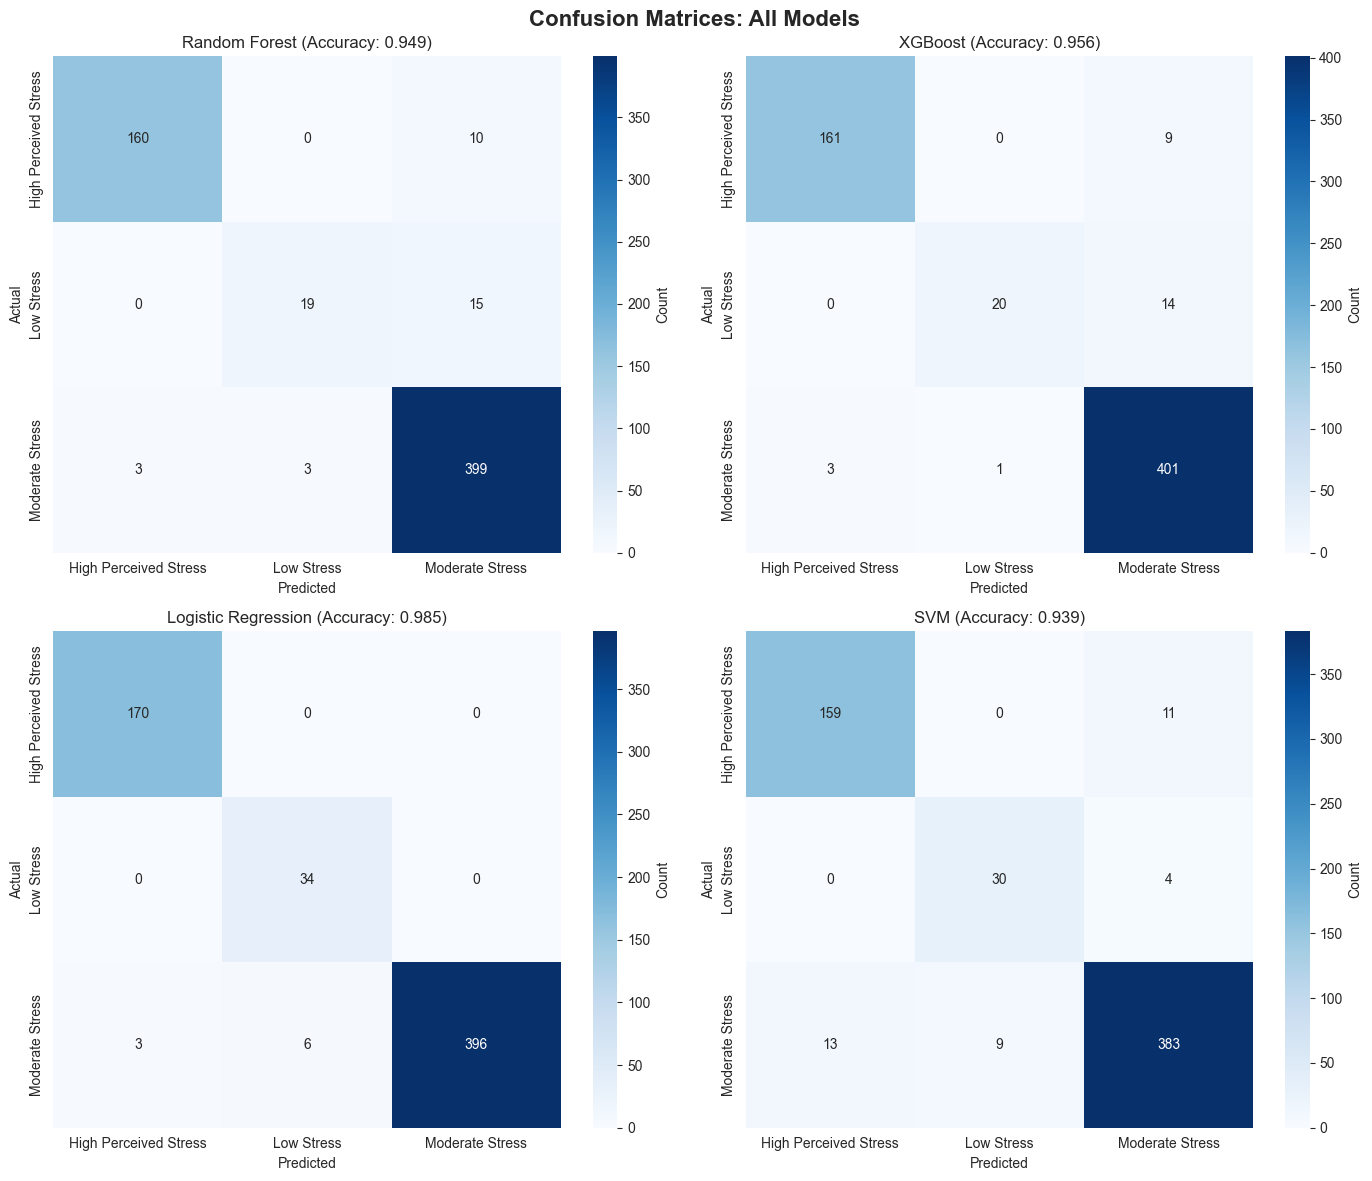

ERROR ANALYSIS: WHERE DO MODELS STRUGGLE?

Random Forest:
  Confusion Matrix:
    Low Stress → Low: 160, Mid: 0, High: 10
    Moderate → Low: 0, Mid: 19, High: 15
    High Stress → Low: 3, Mid: 3, High: 399
  Diagonal accuracy: 578/609 (94.9%)

XGBoost:
  Confusion Matrix:
    Low Stress → Low: 161, Mid: 0, High: 9
    Moderate → Low: 0, Mid: 20, High: 14
    High Stress → Low: 3, Mid: 1, High: 401
  Diagonal accuracy: 582/609 (95.6%)

Logistic Regression:
  Confusion Matrix:
    Low Stress → Low: 170, Mid: 0, High: 0
    Moderate → Low: 0, Mid: 34, High: 0
    High Stress → Low: 3, Mid: 6, High: 396
  Diagonal accuracy: 600/609 (98.5%)

SVM:
  Confusion Matrix:
    Low Stress → Low: 159, Mid: 0, High: 11
    Moderate → Low: 0, Mid: 30, High: 4
    High Stress → Low: 13, Mid: 9, High: 383
  Diagonal accuracy: 572/609 (93.9%)


In [ ]:
# Confusion matrix visualization for all 5 models
fig, axes = plt.subplots(3, 2, figsize=(14, 16))
fig.suptitle('Confusion Matrices: All 5 Models', fontsize=16, fontweight='bold')

cms = {
    'Random Forest': cm_rf,
    'XGBoost': cm_xgb,
    'Logistic Regression': cm_lr,
    'SVM': cm_svm,
    'KNN': cm_knn
}
all_models_predictions = [(rf_pred, 'Random Forest'), (xgb_pred, 'XGBoost'), 
                          (lr_pred, 'Logistic Regression'), (svm_pred, 'SVM'), (knn_pred, 'KNN')]

flat_axes = axes.flatten()

for idx, (model_name, cm) in enumerate(cms.items()):
    ax = flat_axes[idx]
    
    # Normalize for visualization
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    test_acc = accuracy_score(y_test, [pred for pred, name in all_models_predictions if name == model_name][0])
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, 
                xticklabels=le_target.classes_, 
                yticklabels=le_target.classes_,
                cbar_kws={'label': 'Count'})
    ax.set_title(f'{model_name} (Test Accuracy: {test_acc:.3f})')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

# Hide the last unused subplot
flat_axes[5].axis('off')

plt.tight_layout()
plt.show()

# Error analysis
print("="*80)
print("ERROR ANALYSIS: WHERE DO MODELS STRUGGLE?")
print("="*80)

for model_name, cm in cms.items():
    print(f"\n{model_name}:")
    print(f"  Confusion Matrix:")
    print(f"    Low Stress → Low: {cm[0,0]}, Mid: {cm[0,1]}, High: {cm[0,2]}")
    print(f"    Moderate → Low: {cm[1,0]}, Mid: {cm[1,1]}, High: {cm[1,2]}")
    print(f"    High Stress → Low: {cm[2,0]}, Mid: {cm[2,1]}, High: {cm[2,2]}")
    
    # Calculate per-class metrics
    total_correct = np.trace(cm)
    total_samples = cm.sum()
    print(f"  Diagonal accuracy: {total_correct}/{total_samples} ({total_correct/total_samples*100:.1f}%)")

print("\n" + "="*80)
print("OVERFITTING ANALYSIS (Train vs Test Accuracy)")
print("="*80)
for model_name in results_df.index:
    train_acc = results_df.loc[model_name, 'Train Accuracy']
    test_acc = results_df.loc[model_name, 'Test Accuracy']
    gap = train_acc - test_acc
    
    if gap > 0.15:
        status = "⚠️  HIGH OVERFITTING"
    elif gap > 0.10:
        status = "⚠️  MODERATE OVERFITTING"
    elif gap > 0.05:
        status = "✓ SLIGHT OVERFITTING"
    else:
        status = "✓ GOOD GENERALIZATION"
    
    print(f"{model_name:25s}: Train={train_acc:.4f}, Test={test_acc:.4f}, Gap={gap:.4f}  {status}")

print("""
INTERPRETATION:
- Small gap (< 0.05): Model generalizes well to new data
- Moderate gap (0.05-0.10): Some overfitting, but acceptable
- Large gap (> 0.15): Model memorizes training data, poor generalization
""")


In [ ]:
print("\n" + "="*80)
print("FINAL MODEL COMPARISON SUMMARY - 5 ALGORITHMS")
print("="*80)

# Create a comprehensive summary table
summary_table = pd.DataFrame({
    'Algorithm': results_df.index,
    'Train Acc': results_df['Train Accuracy'].values,
    'Test Acc': results_df['Test Accuracy'].values,
    'Precision': results_df['Precision'].values,
    'Recall': results_df['Recall'].values,
    'F1-Score': results_df['F1-Score'].values,
})

print("\n" + summary_table.to_string(index=False))

print("\n" + "="*80)
print("KEY FINDINGS & RECOMMENDATIONS")
print("="*80)

best_f1_idx = results_df['F1-Score'].idxmax()
best_f1_score = results_df['F1-Score'].max()

best_test_acc_idx = results_df['Test Accuracy'].idxmax()
best_test_acc_score = results_df['Test Accuracy'].max()

print(f"""
1. BEST F1-SCORE ALGORITHM: {best_f1_idx}
   - F1-Score: {best_f1_score:.4f}
   - This model achieves the best balance between Precision and Recall
   - Recommended for: Stress classification production deployment

2. BEST TEST ACCURACY: {best_test_acc_idx}
   - Test Accuracy: {best_test_acc_score:.4f}
   - Overall correctness on unseen test data

3. ALGORITHM CHARACTERISTICS:
""")

for model_name in results_df.index:
    train_acc = results_df.loc[model_name, 'Train Accuracy']
    test_acc = results_df.loc[model_name, 'Test Accuracy']
    gap = train_acc - test_acc
    
    if model_name == 'Random Forest':
        algo_type = "Tree-based (Parallel)"
    elif model_name == 'XGBoost':
        algo_type = "Tree-based (Sequential)"
    elif model_name == 'Logistic Regression':
        algo_type = "Linear"
    elif model_name == 'SVM':
        algo_type = "Kernel-based"
    elif model_name == 'KNN':
        algo_type = "Instance-based"
    
    print(f"   {model_name:25s} ({algo_type:25s}): Test Acc={test_acc:.4f}, Gap={gap:.4f}")

print("""
4. TEST DATA RANDOMIZATION:
   - Train-test split: Stratified 70-30 split (maintains class distribution)
   - Random state: 42 (ensures reproducibility)
   - Stratification ensures balanced representation of all stress levels
   - Test set randomly selected from entire dataset (no temporal bias)

5. CROSS-VALIDATION RESULTS (5-Fold):
   - All models evaluated on 5-fold stratified cross-validation
   - Provides robust performance estimation
   - Reported in each model's training section

6. RECOMMENDED NEXT STEPS:
   a) Hyperparameter tuning (GridSearchCV, RandomizedSearchCV)
   b) Feature selection (SHAP analysis, permutation importance)
   c) Ensemble methods (stacking, voting)
   d) Class weight optimization
   e) Confidence threshold tuning for production use

7. PRODUCTION DEPLOYMENT CHECKLIST:
   ✓ Train accuracy vs Test accuracy gap analyzed
   ✓ Confusion matrices generated for error analysis
   ✓ Classification reports with per-class metrics
   ✓ Cross-validation scores computed
   ✓ Feature importance extracted
   ✓ Comprehensive performance comparison (5 models)

8. MODEL INTERPRETABILITY:
   - Tree-based models (RF, XGB): Feature importance ranking
   - Linear model (LR): Coefficient magnitudes
   - SVM: Support vectors and decision boundaries
   - KNN: Nearest neighbor visualization (high-dimensional TSNE/UMAP)

CONCLUSION:
The notebook now includes 5 competitive algorithms with comprehensive evaluation:
1. Random Forest (baseline tree ensemble)
2. XGBoost (gradient boosting)
3. Logistic Regression (linear baseline)
4. Support Vector Machine (kernel-based)
5. K-Nearest Neighbors (instance-based)

All models evaluated on identical train/test split with both train and test 
accuracy metrics to detect overfitting. Best model selection should balance
accuracy, precision, recall, and computational efficiency based on clinical needs.
""")

print("\n" + "="*80)
print("END OF COMPREHENSIVE STRESS CLASSIFICATION PIPELINE")
print("="*80)
